Description...

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import crudo

from   iminuit import Minuit
from   iminuit.cost import LeastSquares
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import yaml

# Styling Plot
crudo.pt.ccortesp_plot_style()
# PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Runs Information

In [2]:
RUNS_INFO =  {  'Ar': [ # July 2026
                        # {'run_number': 16047, 'extra': ''    },
                        # {'run_number': 16057, 'extra': ''    },
                        {'run_number': 16047, 'extra': '20260727'},  # Changes in Irene by Gonzalo (20260727)
                        {'run_number': 16057, 'extra': '20260727'}
                      ],

                'Xe': [

                      ]
             }

BASE_PATH = '/lhome/ific/c/ccortesp/Data/Cmmssnng/h5/'

# Selected Data

In [3]:
SEL_DICT = {}

print('Loading selected data for:')
for run in RUNS_INFO['Ar']:

    run_id = run['run_number']
    extra  = run['extra']
    # Construct a clean, descriptive dictionary key
    key = f"{run_id}_{extra}" if extra else f"{run_id}"
    print(f"  Run {key}")

    # Load and assign the data, we add the run_id to the dataframes
    # for the global event ID computing
    doro_df = pd.read_hdf(os.path.join(BASE_PATH, 'run_' + key + '_selected.h5'), key='DST/Events')
    doro_df['run_id'] = run_id  

    soph_df = pd.read_hdf(os.path.join(BASE_PATH, 'run_' + key + '_selected.h5'), key='RECO/Events')
    soph_df['run_id'] = run_id

    SEL_DICT[key] = {}
    SEL_DICT[key]['doro_df'] = doro_df
    SEL_DICT[key]['soph_df'] = soph_df

Loading selected data for:
  Run 16047_20260727
  Run 16057_20260727


# Joint Data

In [4]:
doro_dfs, soph_dfs = [], []
for key in SEL_DICT.keys():
    doro_dfs.append(SEL_DICT[key]['doro_df'])
    soph_dfs.append(SEL_DICT[key]['soph_df'])

DORO_DF = pd.concat(doro_dfs, ignore_index=True)
SOPH_DF = pd.concat(soph_dfs, ignore_index=True)

### Global Event ID

In [5]:
COMP_COLS = ['event', 'run_id']

for name, df in zip(['Dorothea', 'Sophronia'], [DORO_DF, SOPH_DF]):

    print(f"Processing {name}")
    # An original event is defined as a row in dataframe where at least one of the columns 
    # ('event', 'run_id') differs from the corresponding row below it (using `shift`).
    event_OG = (df[COMP_COLS] != df[COMP_COLS].shift())

    # If any column in event_OG is True, it means the row corresponds to the start of a new original event block.
    new_event_block = event_OG.any(axis=1)

    # Use `cumsum()` on the boolean mask to create a unique identifier for each contiguous block of hits 
    # that belong to the same original event.
    unique_block_id = new_event_block.cumsum()

    # Assign a unique global event ID to each block of original events.
    # The `factorize` function generates a unique integer code for each unique block ID.
    df['global_event'] = pd.factorize(unique_block_id)[0]

Processing Dorothea
Processing Sophronia


### Extra Steps

1. Let's create a _clean_ Sophronia dataframe without spurious hits

In [6]:
CLEAN_SOPH_DF = crudo.tf.deal_spurious_hits(SOPH_DF, energy_column='E', output_column='E_hit_pe')

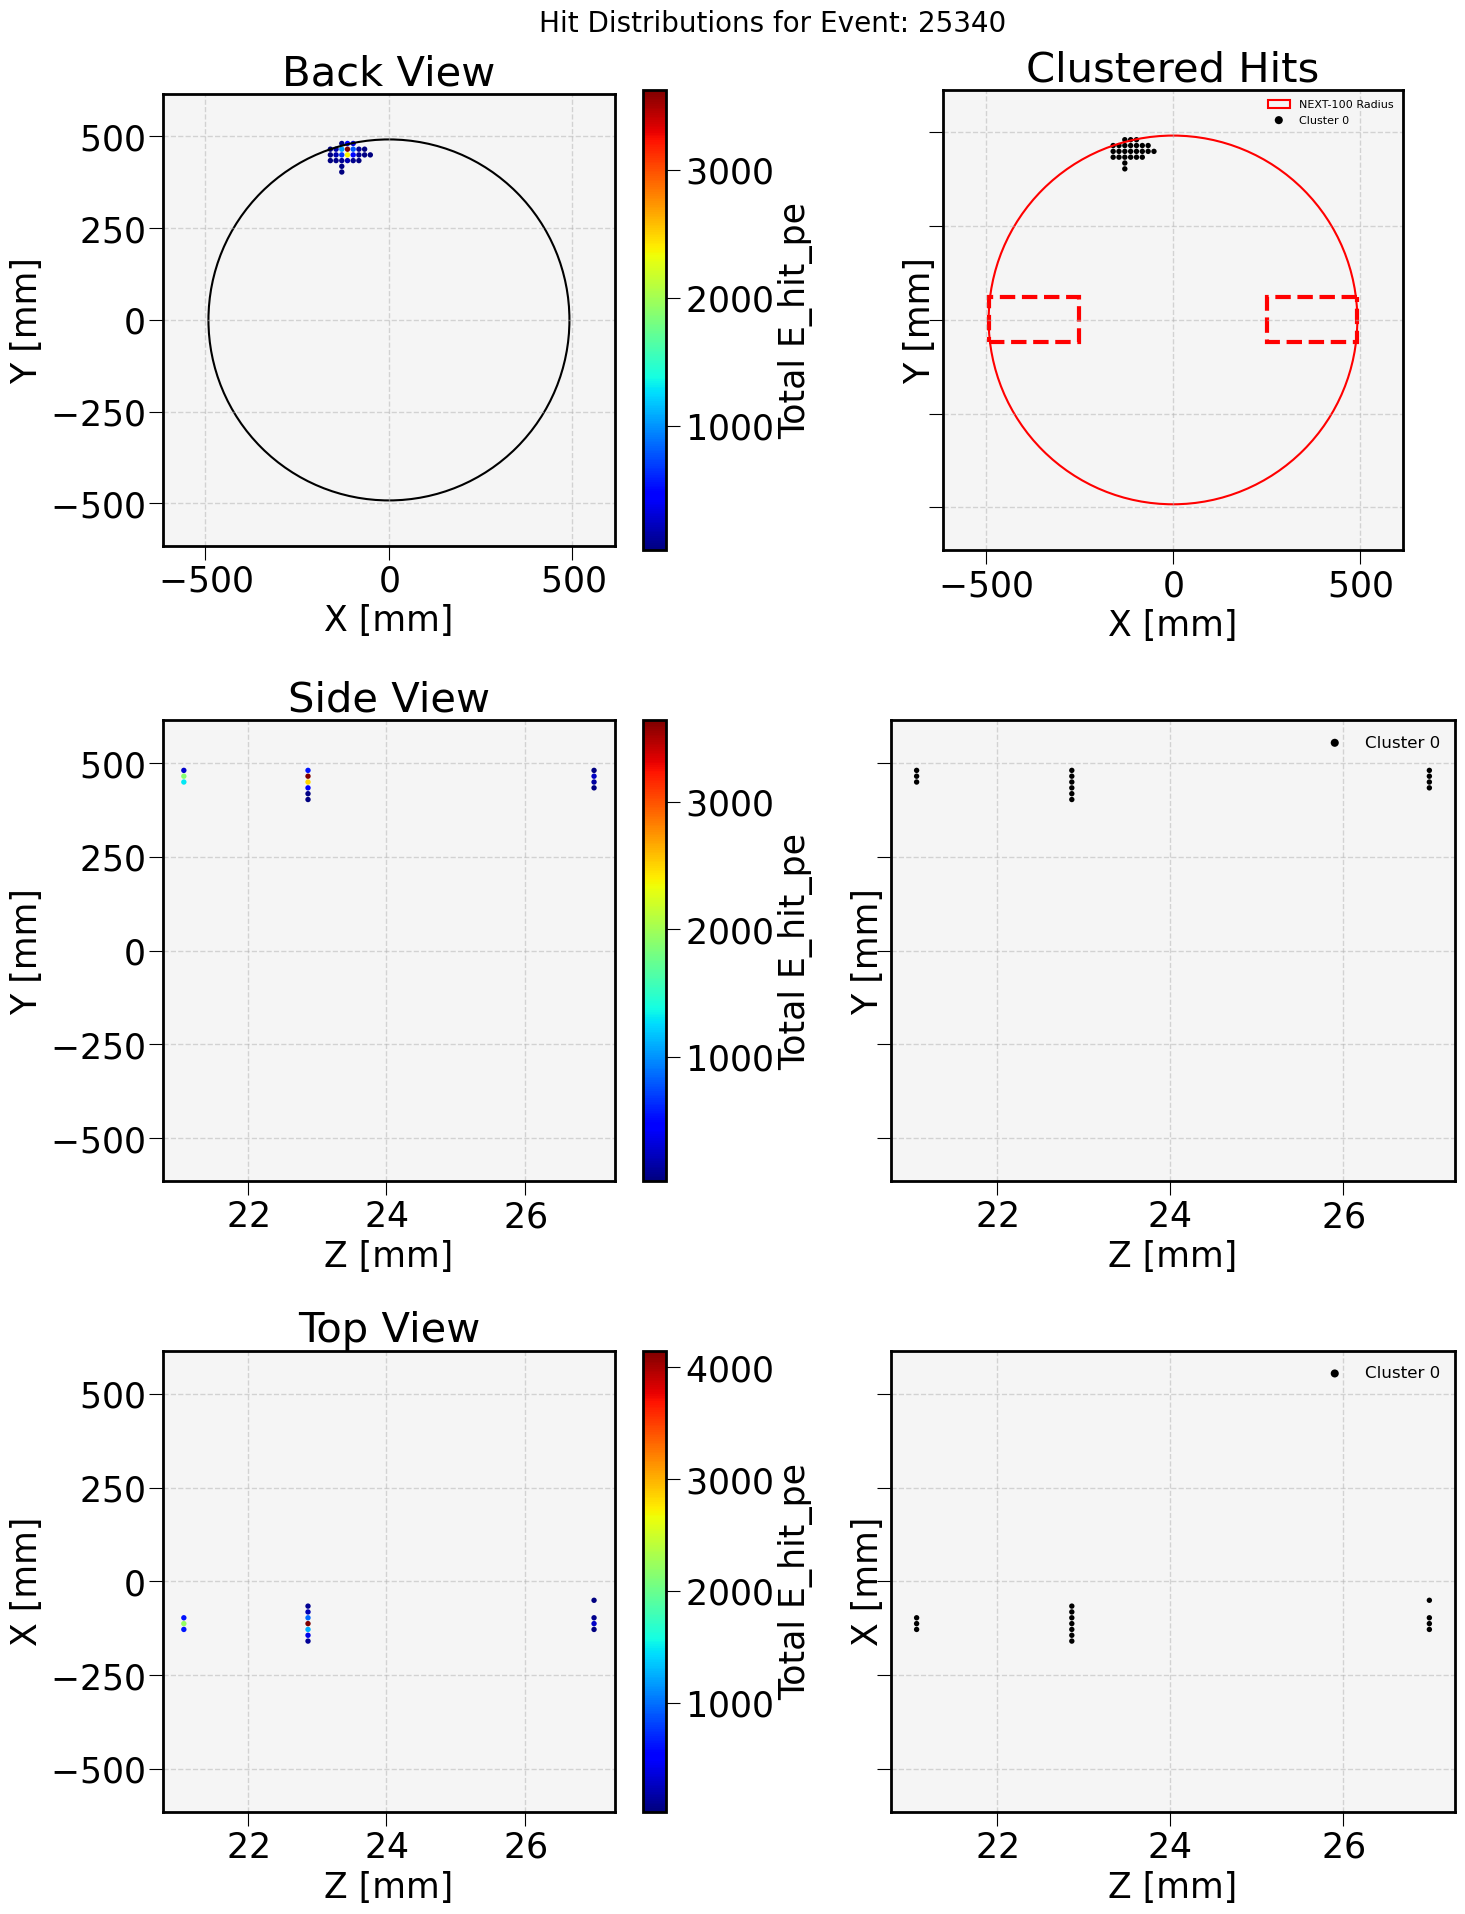

In [7]:
crudo.pt.display_event_cluster(CLEAN_SOPH_DF, variable='E_hit_pe', event_column='global_event')

Also, let's construct a clean-sophronia-based dataframe at event-level

In [8]:
EVENT_INFO_DF = crudo.dm.summarize_hits_to_event_level(CLEAN_SOPH_DF, event_column='global_event', energy_column='E_hit_pe')
EVENT_INFO_DF

,global_event,E_evt,n_cluster,n_hits,X_bary,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max
0,0,15230.394227,1,50,-150.691034,-313.088921,84.312636,-206.225,-97.375,-359.025,-265.725,82.696125,88.742250,392.890737
1,1,9647.848758,1,40,110.160948,337.567691,528.636160,73.675,151.425,309.625,371.825,526.278125,533.067250,401.476477
2,2,22459.303955,1,74,12.766892,-27.959664,367.775471,-50.725,89.225,-79.125,29.725,363.132125,373.236750,90.816057
3,3,24467.452694,1,87,-161.222559,-207.503885,527.499727,-221.775,-112.925,-250.175,-141.325,525.020875,536.168625,324.216411
4,4,23210.403403,1,81,-100.553016,-39.209058,527.033876,-159.575,-35.175,-94.675,14.175,521.407625,531.575000,171.772993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83810,83813,24595.892514,1,85,247.885067,80.656576,527.283424,182.525,306.925,29.725,123.025,521.630750,536.074875,325.198142
83811,83814,33172.882361,1,106,-30.491352,-56.584751,525.808690,-81.825,42.575,-125.775,14.175,519.313375,533.578375,126.297372
83812,83815,19468.286939,1,72,-257.190048,36.629670,314.062185,-315.075,-206.225,-16.925,107.475,312.643375,319.595625,315.078000
83813,83816,13082.538238,1,58,19.049216,-418.031889,527.150820,-19.625,58.125,-452.325,-374.575,524.657750,535.623500,456.044319


In [9]:
list_removed_evts = np.setdiff1d(DORO_DF['global_event'].unique(), EVENT_INFO_DF['global_event'].unique())
print(f"Removed events due to spurious hits: {list_removed_evts}")

Removed events due to spurious hits: [16821 42282 49909]


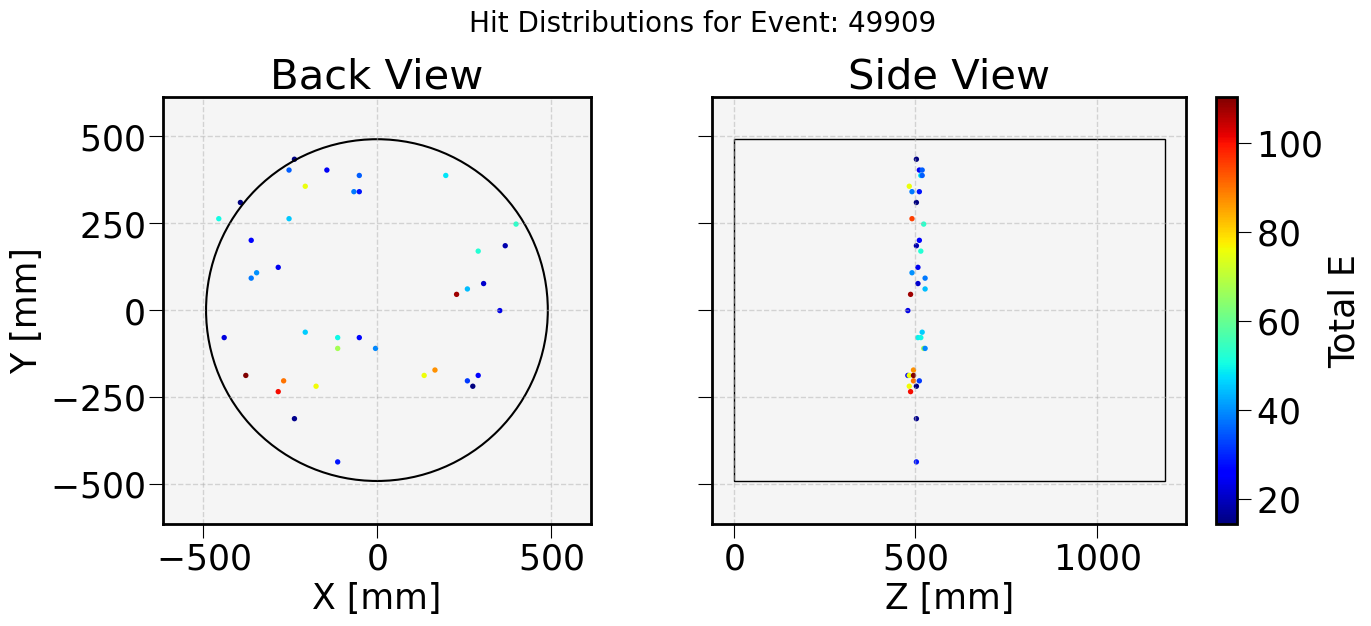

In [10]:
crudo.pt.event_display(SOPH_DF, variable='E', event_column='global_event', event=49909)

Remove these events from all the dataframe for sanity in the comparisons!

In [11]:
DORO_DF = DORO_DF[~DORO_DF['global_event'].isin(list_removed_evts)].copy()

In [12]:
DORO_DF

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Z,Zrms,X,Y,R,Phi,Xrms,Yrms,run_id,global_event
0,1,1.784798e+09,0,0,1,1,375.0,9.748066,76.116409,1518450.0,...,84.418877,2.340653,-151.147754,-314.290778,348.746809,-2.019061,12.225466,13.285127,16047,0
1,8,1.784798e+09,0,0,1,1,1075.0,18.987965,156.188171,1075200.0,...,528.738403,2.730355,110.144318,337.879085,355.378737,1.255672,13.369742,12.333677,16047,1
2,15,1.784798e+09,0,0,1,1,300.0,13.149719,89.383507,1236075.0,...,366.947388,3.794941,12.438813,-27.992375,30.631636,-1.152639,13.982804,14.571225,16047,2
3,29,1.784798e+09,0,0,1,1,1150.0,19.960472,186.114441,1077475.0,...,527.490662,6.216402,-161.245239,-207.862581,263.072005,-2.230562,16.436524,14.778878,16047,3
4,36,1.784798e+09,0,0,1,1,350.0,14.803468,109.077393,1077725.0,...,527.236755,6.027556,-100.956162,-38.659718,108.105136,-2.775883,14.790812,15.515636,16047,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83813,51716,1.784980e+09,0,0,1,1,575.0,19.112818,120.796349,1077500.0,...,527.464905,8.916667,240.799452,80.398562,253.866707,0.322244,51.051457,29.569447,16057,83813
83814,51730,1.784980e+09,0,0,1,1,2125.0,21.479023,266.143982,1078825.0,...,525.176147,9.565093,-27.427228,-58.695773,64.787705,-2.007925,51.645186,42.128288,16057,83814
83815,51737,1.784980e+09,0,0,1,1,400.0,10.611453,75.582512,1288700.0,...,313.311768,4.585225,-255.542047,31.835407,257.517438,3.017651,24.388219,37.667702,16057,83815
83816,51751,1.784980e+09,0,0,1,1,300.0,13.802027,99.195099,1075900.0,...,527.087158,2.739791,20.465066,-417.275985,417.777532,-1.521791,13.184129,13.580263,16057,83816


2. Construct the _active volume_ mask to avoid the cathode

In [13]:
cath_lim = crudo.tf.get_cathode_limit(DORO_DF, n_bins=80, step_back=1)
z_mask    = (DORO_DF['DT'] >= 0) & (DORO_DF['DT'] <= cath_lim)
cath_mask = (DORO_DF['DT'] > cath_lim)

EXTRA_INFO = { 'cath_lim': cath_lim, 'AV_Z_mask': z_mask, 'cath_mask': cath_mask }

Cathode limit = 515.01 μs


Is it enough? let's compare these dorothea-based value with our clean event dataframe

Z = [21.23, 597.58] μs
DT = [-999999.00, 597.11] μs


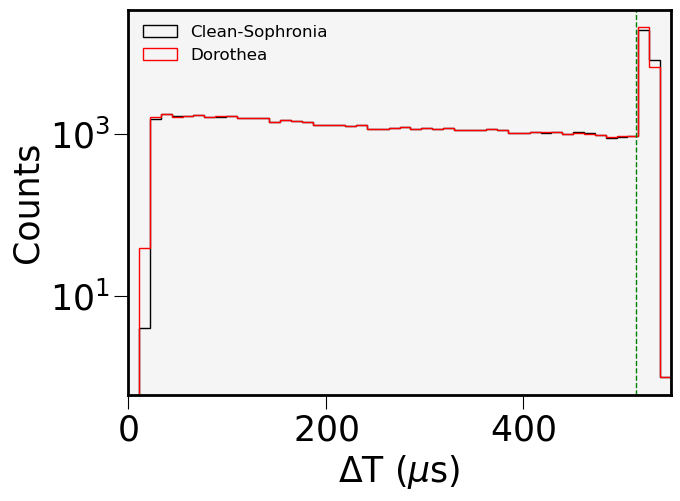

In [14]:
bin_edges = np.linspace(0, 550, 51)

# Clean events
Z_bary = EVENT_INFO_DF['Z_bary']
print(f"Z = [{Z_bary.min():.2f}, {Z_bary.max():.2f}] μs")

# Dorothea
DT = DORO_DF['DT']
print(f"DT = [{DT.min():.2f}, {DT.max():.2f}] μs")

# Histogram
counts, bins, _ = plt.hist(Z_bary, bins=bin_edges, histtype='step', color='black', lw=1.0, label='Clean-Sophronia')
counts, bins, _ = plt.hist(DT, bins=bin_edges, histtype='step', color='red', lw=1.0, label='Dorothea')

# Plot
plt.xlabel('$\Delta$T ($\mu$s)')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(bins[0], bins[-1])
plt.legend(loc='upper left', facecolor='none', fontsize=12)
# Cathode line
plt.axvline(x=EXTRA_INFO['cath_lim'], c='green', ls='--', lw=1)

plt.gca().set_facecolor("whitesmoke")
plt.show()

3. Add new information to the Sophronia dataframes

In [15]:
COLS_TO_ADD = ['global_event', 'Z_bary']     # We merge by 'global_event'

SOPH_DF = SOPH_DF.merge(EVENT_INFO_DF[COLS_TO_ADD], on='global_event', how='left')
CLEAN_SOPH_DF = CLEAN_SOPH_DF.merge(EVENT_INFO_DF[COLS_TO_ADD], on='global_event', how='left')

# Control Plots

### Event-level

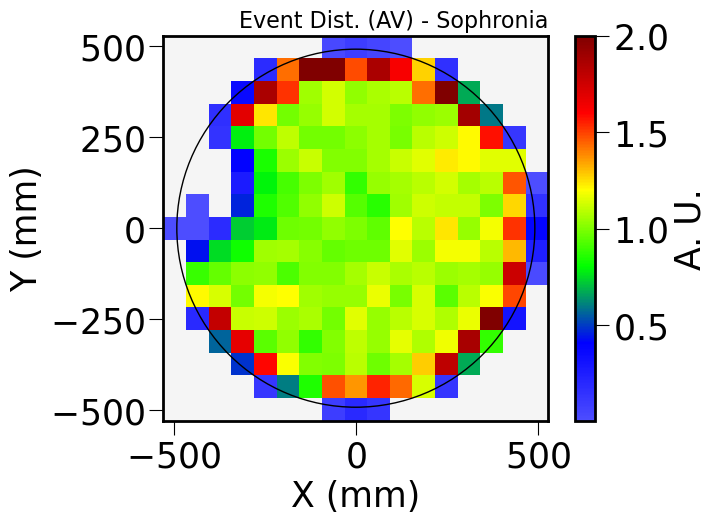

In [16]:
# Variables    
X = EVENT_INFO_DF['X_bary']
Y = EVENT_INFO_DF['Y_bary']
Z = EVENT_INFO_DF['Z_bary']

# Masking
mask = (Z >= 0) & (Z <= EXTRA_INFO['cath_lim'])
X_mask = X[mask]
Y_mask = Y[mask]

# Map
xy_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, bin_scale=4, max_limit=crudo.pt.N100_rad, pos=True, norm=True)
xy_map         = np.ma.masked_where(xy_map==0, xy_map)
xy_map         = np.clip(xy_map, 0, 2)

# Plot
plt.pcolormesh(ex, ey, xy_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
plt.colorbar(label='A. U.')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title (f'Event Dist. (AV) - Sophronia', loc='right', fontsize=16) 

plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().set_facecolor("whitesmoke")
plt.show()

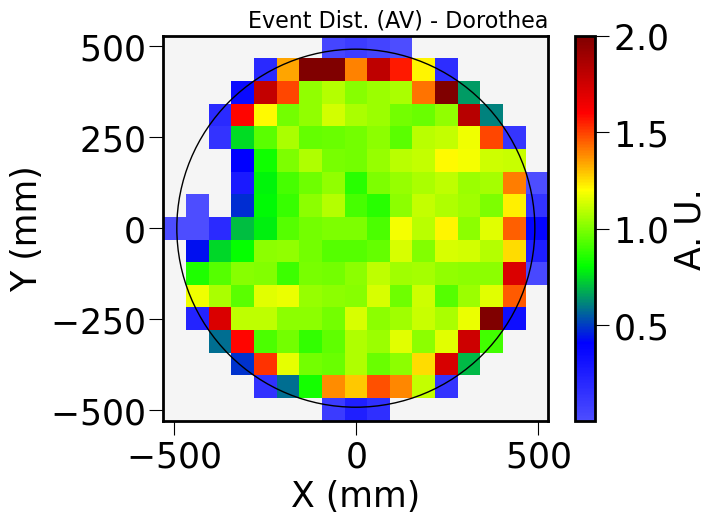

In [17]:
# Variables    
X = DORO_DF['X']
Y = DORO_DF['Y']
DT = DORO_DF['DT']

# Masking
mask = (DT >= 0) & (DT <= EXTRA_INFO['cath_lim'])
X_mask = X[mask]
Y_mask = Y[mask]

# Map
xy_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, bin_scale=4, max_limit=crudo.pt.N100_rad, pos=True, norm=True)
xy_map         = np.ma.masked_where(xy_map==0, xy_map)
xy_map         = np.clip(xy_map, 0, 2)

# Plot
plt.pcolormesh(ex, ey, xy_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
plt.colorbar(label='A. U.')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title (f'Event Dist. (AV) - Dorothea', loc='right', fontsize=16) 

plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().set_facecolor("whitesmoke")
plt.show()

### Hit-level

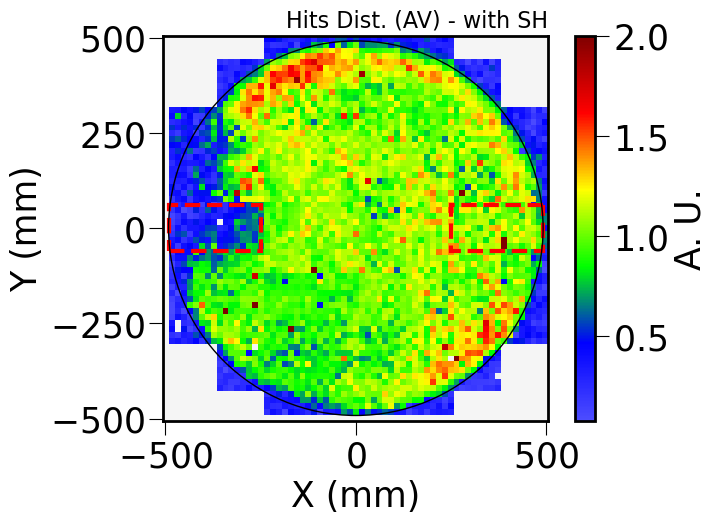

In [18]:
# Variables    
X = SOPH_DF['X']
Y = SOPH_DF['Y']
Z = SOPH_DF['Z_bary']

# Masking
mask = (Z >= 0) & (Z <= EXTRA_INFO['cath_lim'])
X_mask = X[mask]
Y_mask = Y[mask]

# Map
xy_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, bin_scale=1, max_limit=crudo.pt.N100_rad, pos=True, norm=True)
xy_map         = np.ma.masked_where(xy_map==0, xy_map)
xy_map         = np.clip(xy_map, 0, 2)

# Plot
plt.pcolormesh(ex, ey, xy_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
plt.colorbar(label='A. U.')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title (f'Hits Dist. (AV) - with SH', loc='right', fontsize=16)

# Region of interest
x_left, x_right = -crudo.pt.N100_rad, -250
y_left, y_right = -60, 60
plt.gca().add_patch(plt.Rectangle((x_left, y_left), x_right - x_left, y_right - y_left, 
                    fill=False, edgecolor='red', ls='--'))
plt.gca().add_patch(plt.Rectangle((-x_left, -y_left), - (x_right - x_left), - (y_right - y_left), 
                    fill=False, edgecolor='red', ls='--'))
# plt.gca().add_patch(crudo.pt.plot_circle(375, linestyle='--'))


plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().set_facecolor("whitesmoke")
plt.show()

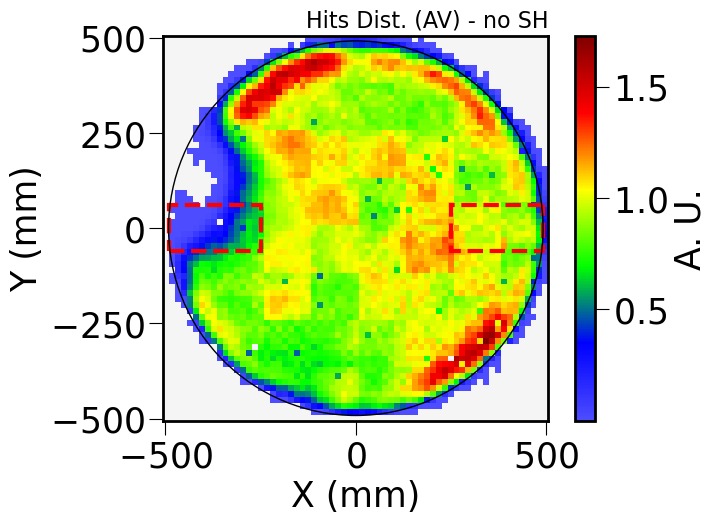

In [19]:
# Variables    
X = CLEAN_SOPH_DF['X']
Y = CLEAN_SOPH_DF['Y']
Z = CLEAN_SOPH_DF['Z_bary']

# Masking
mask = (Z >= 0) & (Z <= EXTRA_INFO['cath_lim'])
X_mask = X[mask]
Y_mask = Y[mask]

# Map
xy_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, bin_scale=1, max_limit=crudo.pt.N100_rad, pos=True, norm=True)
xy_map         = np.ma.masked_where(xy_map==0, xy_map)
xy_map         = np.clip(xy_map, 0, 2)

# Plot
plt.pcolormesh(ex, ey, xy_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
plt.colorbar(label='A. U.')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title (f'Hits Dist. (AV) - no SH', loc='right', fontsize=16)

# Region of interest
x_left, x_right = -crudo.pt.N100_rad, -250
y_left, y_right = -60, 60
plt.gca().add_patch(plt.Rectangle((x_left, y_left), x_right - x_left, y_right - y_left, 
                    fill=False, edgecolor='red', ls='--'))
plt.gca().add_patch(plt.Rectangle((-x_left, -y_left), - (x_right - x_left), - (y_right - y_left), 
                    fill=False, edgecolor='red', ls='--'))
# plt.gca().add_patch(crudo.pt.plot_circle(375, linestyle='--'))


plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().set_facecolor("whitesmoke")
plt.show()

# Trapped α?

Are these guys really trapped? or maybe is a reconstruction problem?
<br>
Let's compare both Dorothea and Sophronia information

E_evt = [652.31, 53460.64] PE
E2 = [2291.74, 54504.25] PE


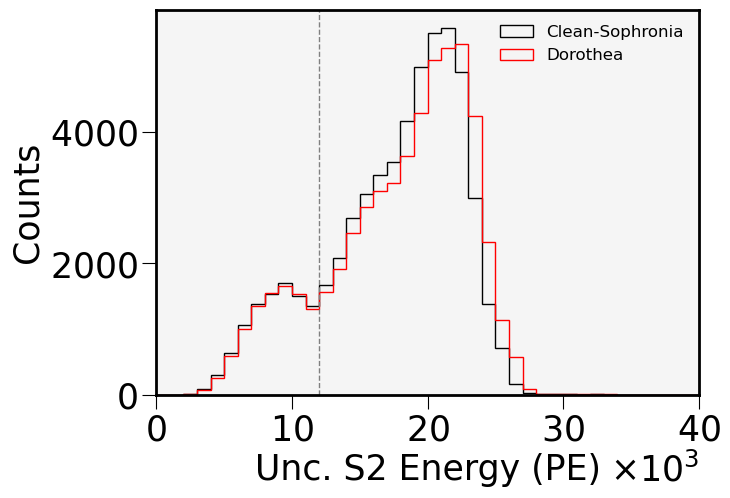

In [20]:
bin_edges = np.linspace(0, 40e3, 41)

# Clean events
E_evt = EVENT_INFO_DF['E_evt'];
Z     = EVENT_INFO_DF['Z_bary']
mask_soph = (Z >= 0) & (Z <= EXTRA_INFO['cath_lim'])
E_evt = E_evt[mask_soph]
print(f"E_evt = [{E_evt.min():.2f}, {E_evt.max():.2f}] PE")

# Dorothea
E2 = DORO_DF['S2e']
DT = DORO_DF['DT']
mask_doro = (DT >= 0) & (DT <= EXTRA_INFO['cath_lim'])
E2 = E2[mask_doro]
print(f"E2 = [{E2.min():.2f}, {E2.max():.2f}] PE")

# Histogram
counts, bins, _ = plt.hist(E_evt, bins=bin_edges, histtype='step', color='black', lw=1.0, label='Clean-Sophronia')
counts, bins, _ = plt.hist(E2, bins=bin_edges, histtype='step', color='red', lw=1.0, label='Dorothea')

# Plot
plt.xlabel('Unc. S2 Energy (PE)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.xlim(bin_edges[0], bin_edges[-1])
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend(loc='upper right', facecolor='none', fontsize=12)
# Cut line
plt.axvline(x=12e3, c='gray', ls='--', lw=1)

plt.gca().set_facecolor("whitesmoke")
plt.show()

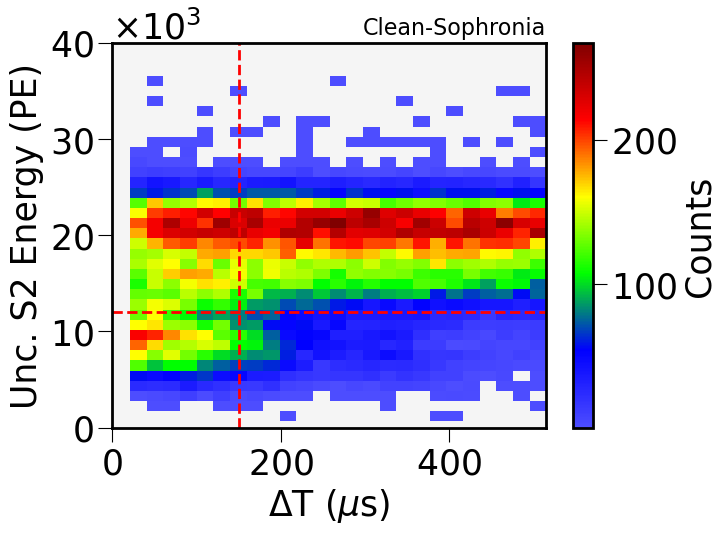

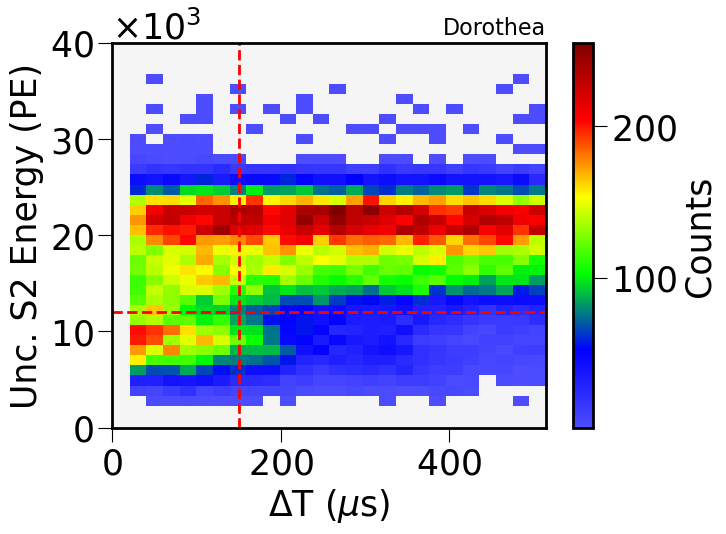

In [21]:
for (temp_df, var), name in zip(zip([EVENT_INFO_DF, DORO_DF], ['Z_bary', 'DT']), ['Clean-Sophronia', 'Dorothea']):

    # Variables
    S2e = temp_df['S2e'] if name == 'Dorothea' else temp_df['E_evt']
    DT  = temp_df[var]

    # Masking
    mask = (DT >= 0) & (DT <= EXTRA_INFO['cath_lim'])
    S2e_mask = S2e[mask]
    DT_mask  = DT[mask]

    # 2D Histogram
    s2e_dt_map, ex, ey = np.histogram2d(DT_mask, S2e_mask, bins=[25, 50])
    s2e_dt_map         = np.ma.masked_where(s2e_dt_map==0, s2e_dt_map)

    # Plot
    plt.pcolormesh(ex, ey, s2e_dt_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    plt.colorbar(label='Counts')
    plt.xlabel('$\Delta$T ($\mu$s)')
    plt.xlim(0, DT_mask.max())
    plt.ylim(0, 40e3)
    plt.ylabel('Unc. S2 Energy (PE)')
    plt.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
    plt.title(f'{name}', loc='right', fontsize=16)

    # Lines
    plt.axvline(x=150, c='red', ls='--')
    plt.axhline(y=12e3, c='red', ls='--')

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

We define as _trapped_ to the events with an energy below 12e3 PE

In [22]:
DORO_DF['trapped']       = np.where(DORO_DF['S2e'] <= 12e3, True, False)
EVENT_INFO_DF['trapped'] = np.where(EVENT_INFO_DF['E_evt'] <= 12e3, True, False)

# Add this information to clean sophronia dataframe
CLEAN_SOPH_DF = CLEAN_SOPH_DF.merge(EVENT_INFO_DF[['global_event', 'trapped']], on='global_event', how='left')

---

In [ ]:
bin_edges = np.linspace(0, 40e3, 41)

# Clean events
E_evt = EVENT_INFO_DF['E_evt'];
Z     = EVENT_INFO_DF['Z_bary']
mask_soph = (Z >= 0) & (Z <= EXTRA_INFO['cath_lim'])
E_evt = E_evt[mask_soph]
print(f"E_evt = [{E_evt.min():.2f}, {E_evt.max():.2f}] PE")

# Dorothea
E2 = DORO_DF['S2e']
DT = DORO_DF['DT']
mask_doro = (DT >= 0) & (DT <= EXTRA_INFO['cath_lim'])
E2 = E2[mask_doro]
print(f"E2 = [{E2.min():.2f}, {E2.max():.2f}] PE")

# Histogram
counts, bins, _ = plt.hist(E_evt, bins=bin_edges, histtype='step', color='black', lw=1.0, label='Clean-Sophronia')
counts, bins, _ = plt.hist(E2, bins=bin_edges, histtype='step', color='red', lw=1.0, label='Dorothea')

# Plot
plt.xlabel('Unc. S2 Energy (PE)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.xlim(bin_edges[0], bin_edges[-1])
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.legend(loc='upper right', facecolor='none', fontsize=12)
# Cut line
plt.axvline(x=12e3, c='gray', ls='--', lw=1)

plt.gca().set_facecolor("whitesmoke")
plt.show()

DT = [21.18, 514.86] μs
- There are 8 negative DT values


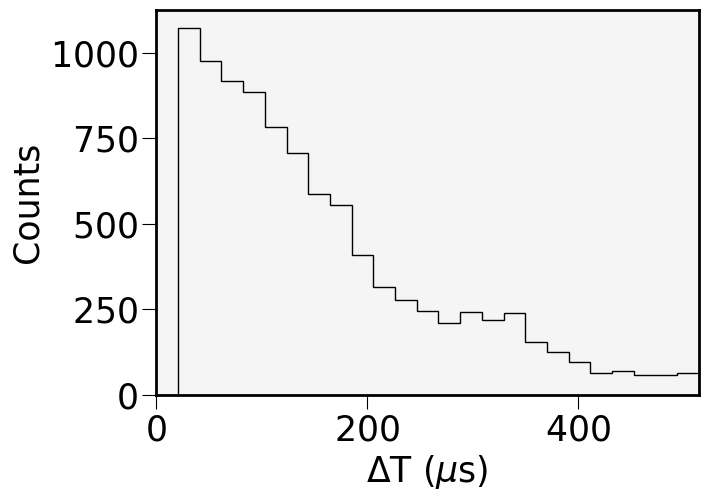

In [ ]:
# Variables
DT = DORO_DF['DT']

mask = (DORO_DF['trapped'] == True) & EXTRA_INFO['AV_Z_mask']
DT_mask = DT[mask]
print(f"DT = [{DT_mask.min():.2f}, {DT_mask.max():.2f}] μs")

# Negative DT's?
negative_DT = DORO_DF[DT < 0]    
if not negative_DT.empty:
    print(f"- There are {len(negative_DT)} negative DT values")
else:
    print(f"- No negative DT values found")

# Histogram
counts, bins, _ = plt.hist(DT_mask, bins=25, range=(0, DT_mask.max()), histtype='step', color='black', lw=1.0)


# Plot
plt.xlabel('$\Delta$T ($\mu$s)')
plt.ylabel('Counts')
# plt.yscale('log')
plt.xlim(bins[0], bins[-1])

plt.gca().set_facecolor("whitesmoke")
plt.show()

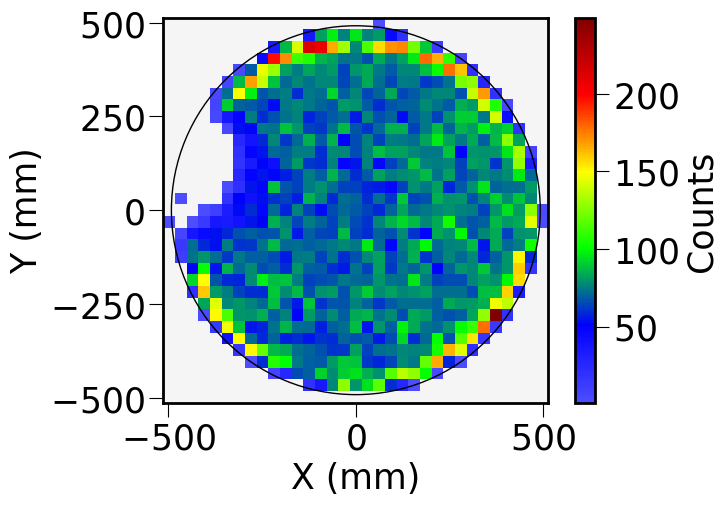

In [ ]:
# Variables    
X = DORO_DF['X']
Y = DORO_DF['Y']

# Masking
mask = (DORO_DF['trapped'] == True) & (EXTRA_INFO['AV_Z_mask']) 
X_mask = X[mask]
Y_mask = Y[mask]

# Map
xy_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, bin_scale=2, max_limit=crudo.pt.N100_rad, pos=True, norm=False)
xy_map         = np.ma.masked_where(xy_map==0, xy_map)
# xy_map         = np.clip(xy_map, 0.5, 1.5)

# Plot
plt.pcolormesh(ex, ey, xy_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
plt.colorbar(label='Counts')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
# plt.title (f'Event Dist. (AV) - Run {key}', loc='center', fontsize=16) 

plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().set_facecolor("whitesmoke")
plt.show()

In [ ]:
SOPH_DF

,event,time,npeak,Xpeak,Ypeak,X,Y,Z,Q,E,Ec,cluster,run_id,global_event,trapped,DT
0,1,1.784798e+09,0,-151.147754,-314.290778,-330.625,-343.475,82.696125,6.936389,151.261706,0.001339,-1,16047,0,False,84.418877
1,1,1.784798e+09,0,-151.147754,-314.290778,-283.975,-250.175,82.696125,5.507809,120.108682,0.000518,-1,16047,0,False,84.418877
2,1,1.784798e+09,0,-151.147754,-314.290778,-330.625,247.425,82.696125,5.774110,125.915906,0.000559,-1,16047,0,False,84.418877
3,1,1.784798e+09,0,-151.147754,-314.290778,-128.475,-483.425,82.696125,9.804965,213.816691,0.001956,-1,16047,0,False,84.418877
4,1,1.784798e+09,0,-151.147754,-314.290778,-175.125,-312.375,82.696125,6.805732,148.412477,0.000621,0,16047,0,False,84.418877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9247058,51758,1.784980e+09,0,-277.005257,163.356138,-159.575,-421.225,549.794625,5.327367,6.830802,0.000034,-1,16057,83817,False,527.087158
9247059,51758,1.784980e+09,0,-277.005257,163.356138,-66.275,-390.125,549.794625,5.151600,6.605432,0.000029,-1,16057,83817,False,527.087158
9247060,51758,1.784980e+09,0,-277.005257,163.356138,120.325,-405.675,549.794625,5.783198,7.415273,0.000034,-1,16057,83817,False,527.087158
9247061,51758,1.784980e+09,0,-277.005257,163.356138,73.675,-32.475,549.794625,6.119465,7.846438,0.000031,-1,16057,83817,False,527.087158


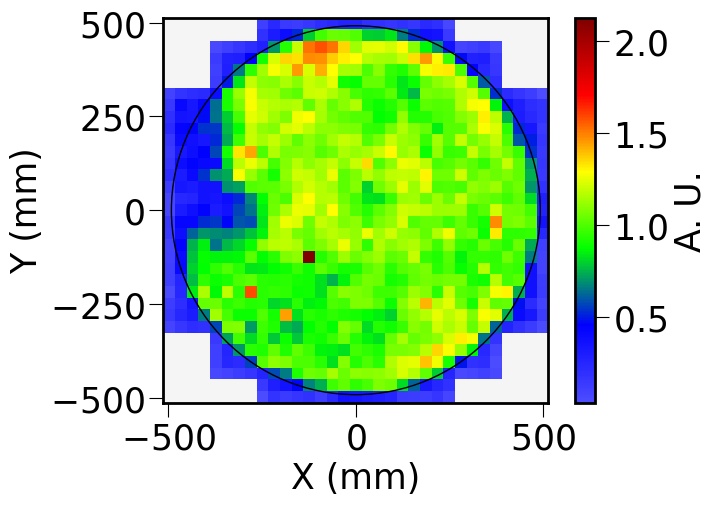

In [ ]:
# Variables    
X = SOPH_DF['X']
Y = SOPH_DF['Y']
DT = SOPH_DF['DT']

# Masking
mask = (SOPH_DF['trapped'] == True) & (DT >= 0) & (DT <= EXTRA_INFO['cath_lim'])
X_mask = X[mask]
Y_mask = Y[mask]

# Map
xy_map, ex, ey = crudo.pt.mapping(X_mask, Y_mask, bin_scale=2, max_limit=crudo.pt.N100_rad, pos=True, norm=True)
xy_map         = np.ma.masked_where(xy_map==0, xy_map)
# xy_map         = np.clip(xy_map, 0.5, 1.5)

# Plot
plt.pcolormesh(ex, ey, xy_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
plt.colorbar(label='A. U.')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
# plt.title (f'Event Dist. (AV) - Run {key}', loc='center', fontsize=16) 

plt.gca().add_patch(crudo.pt.plot_circle(crudo.pt.N100_rad))
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().set_facecolor("whitesmoke")
plt.show()

## IC is Right?

In [ ]:
SOPH_DF

,event,time,npeak,Xpeak,Ypeak,X,Y,Z,Q,E,Ec,cluster,run_id,global_event,trapped,DT
0,1,1.784798e+09,0,-151.147754,-314.290778,-330.625,-343.475,82.696125,6.936389,151.261706,0.001339,-1,16047,0,False,84.418877
1,1,1.784798e+09,0,-151.147754,-314.290778,-283.975,-250.175,82.696125,5.507809,120.108682,0.000518,-1,16047,0,False,84.418877
2,1,1.784798e+09,0,-151.147754,-314.290778,-330.625,247.425,82.696125,5.774110,125.915906,0.000559,-1,16047,0,False,84.418877
3,1,1.784798e+09,0,-151.147754,-314.290778,-128.475,-483.425,82.696125,9.804965,213.816691,0.001956,-1,16047,0,False,84.418877
4,1,1.784798e+09,0,-151.147754,-314.290778,-175.125,-312.375,82.696125,6.805732,148.412477,0.000621,0,16047,0,False,84.418877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9247058,51758,1.784980e+09,0,-277.005257,163.356138,-159.575,-421.225,549.794625,5.327367,6.830802,0.000034,-1,16057,83817,False,527.087158
9247059,51758,1.784980e+09,0,-277.005257,163.356138,-66.275,-390.125,549.794625,5.151600,6.605432,0.000029,-1,16057,83817,False,527.087158
9247060,51758,1.784980e+09,0,-277.005257,163.356138,120.325,-405.675,549.794625,5.783198,7.415273,0.000034,-1,16057,83817,False,527.087158
9247061,51758,1.784980e+09,0,-277.005257,163.356138,73.675,-32.475,549.794625,6.119465,7.846438,0.000031,-1,16057,83817,False,527.087158


In [ ]:
EVENT_INFO_DF = crudo.dm.summarize_hits_to_event_level(SOPH_DF, event_column='global_event', energy_column='E')

In [ ]:
EVENT_INFO_DF = EVENT_INFO_DF.merge(DORO_DF, on='global_event', how='left')

In [ ]:
EVENT_INFO_DF

,global_event,E_evt,n_cluster,n_hits,X_bary,Y_bary,Z_bary,X_min,X_max,Y_min,...,Z,Zrms,X,Y,R,Phi,Xrms,Yrms,run_id,trapped
0,0,15252.552075,1,92,-142.286806,-283.830433,84.514488,-470.575,477.975,-483.425,...,84.418877,2.340653,-151.147754,-314.290778,348.746809,-2.019061,12.225466,13.285127,16047,False
1,1,10265.060581,1,69,95.025940,295.943033,528.560043,-470.575,462.425,-483.425,...,528.738403,2.730355,110.144318,337.879085,355.378737,1.255672,13.369742,12.333677,16047,True
2,2,23099.322581,1,113,11.170718,-21.129162,368.202395,-392.825,493.525,-467.875,...,366.947388,3.794941,12.438813,-27.992375,30.631636,-1.152639,13.982804,14.571225,16047,False
3,3,25408.273622,1,153,-138.724500,-184.806978,528.495886,-470.575,446.875,-467.875,...,527.490662,6.216402,-161.245239,-207.862581,263.072005,-2.230562,16.436524,14.778878,16047,False
4,4,24402.564119,1,136,-86.202270,-27.750529,528.077375,-392.825,493.525,-483.425,...,527.236755,6.027556,-100.956162,-38.659718,108.105136,-2.775883,14.790812,15.515636,16047,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83813,83813,26163.411860,1,194,214.021306,72.115289,529.303371,-455.025,493.525,-483.425,...,222.961014,6.073088,-129.328737,189.350156,229.301993,2.170031,34.148607,72.117502,16057,False
83814,83814,34777.810402,1,236,-31.197628,-49.002943,527.797584,-486.125,493.525,-467.875,...,527.464905,8.916667,240.799452,80.398562,253.866707,0.322244,51.051457,29.569447,16057,False
83815,83815,20595.179791,1,141,-218.974319,44.934897,314.524555,-470.575,493.525,-483.425,...,525.176147,9.565093,-27.427228,-58.695773,64.787705,-2.007925,51.645186,42.128288,16057,False
83816,83816,13623.335214,1,107,23.138170,-357.126000,527.223050,-439.475,493.525,-452.325,...,313.311768,4.585225,-255.542047,31.835407,257.517438,3.017651,24.388219,37.667702,16057,False


DOROTHEA: DT = [-999999.00, 535.83] mm
SOPHRONIA: DT = [22.14, 598.11] mm


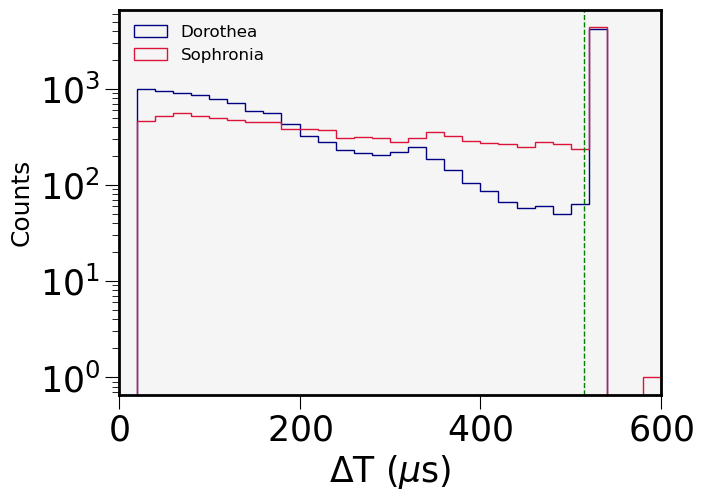

In [ ]:
# Preliminary
bin_edges = np.linspace(0, 600, 31)
colors = ['navy', 'crimson']

for (name, var), color in zip(zip(['Dorothea', 'Sophronia'], ['DT', 'Z_bary']), colors):

    temp_df = EVENT_INFO_DF[EVENT_INFO_DF['trapped'] == True]

    # Variables
    DT = temp_df[var]

    # Masking
    # mask = (DT >= 0) & (DT <= EXTRA_INFO['cath_lim'])
    # DT = DT[mask]
    print(f"{name.upper()}: DT = [{DT.min():.2f}, {DT.max():.2f}] mm")

    # Histogram
    counts, _, _ = plt.hist(DT, bins=bin_edges, density=False, histtype='step', color=color, lw=1.0, label=name)

# Plot
plt.xlabel('$\Delta$T ($\mu$s)')
plt.ylabel('Counts', fontsize=18)
plt.yscale('log')
plt.xlim(bin_edges[0], bin_edges[-1])
# Radial line
plt.axvline(x=EXTRA_INFO['cath_lim'], c='green', ls='--', lw=1.0)
# plt.axvline(x=crudo.pt.N100_rad, c='gray', ls='--', lw=1.0)
# plt.text(crudo.pt.N100_rad, 1.1*counts[0], 'detector limit', c='gray', va='top',  ha='right',  rotation=90, fontsize=12)

plt.legend(loc='upper left', facecolor='none', fontsize=12)
plt.gca().set_facecolor("whitesmoke")
plt.show()

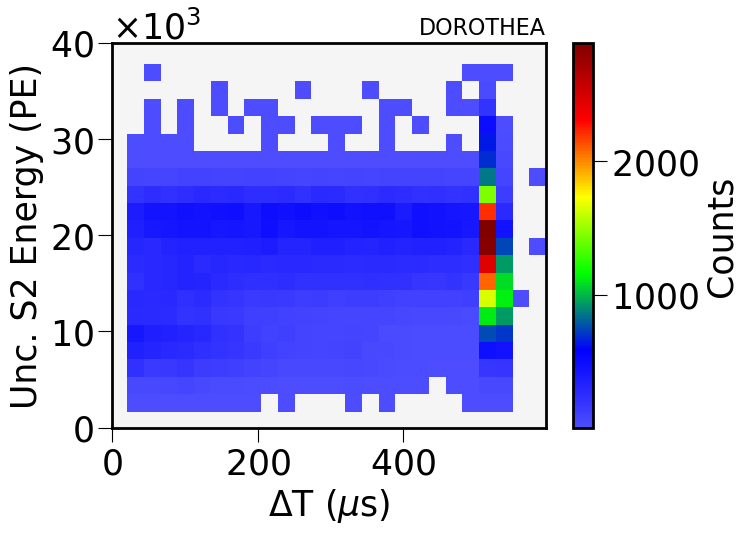

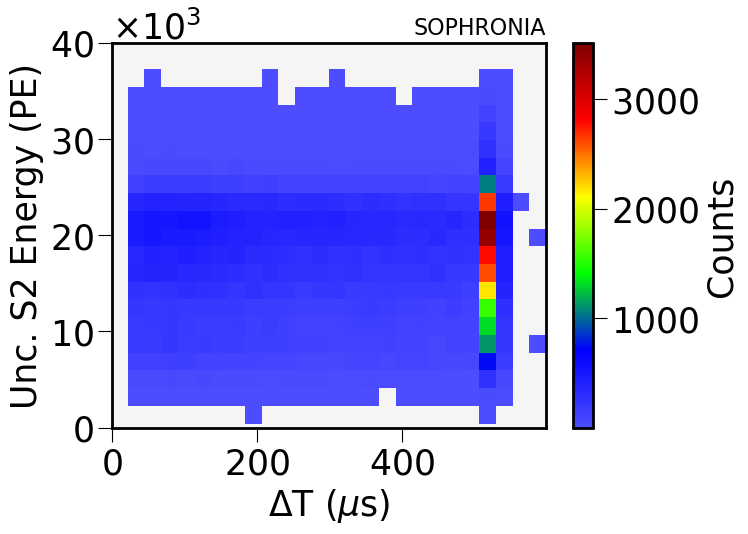

In [ ]:
for name, var in zip(['Dorothea', 'Sophronia'], ['DT', 'Z_bary']):

    temp_df = EVENT_INFO_DF.copy()
    # temp_df = EVENT_INFO_DF[EVENT_INFO_DF['trapped'] == False]

    # Variables
    S2e = temp_df['S2e']
    DT = temp_df[var]

    # Masking
    mask = (DT >= 0) 
    S2e_mask = S2e[mask]
    DT_mask = DT[mask]

    # 2D Histogram
    s2e_dt_map, ex, ey = np.histogram2d(DT_mask, S2e_mask, bins=[25, 35])
    s2e_dt_map         = np.ma.masked_where(s2e_dt_map==0, s2e_dt_map)

    # Plot
    plt.pcolormesh(ex, ey, s2e_dt_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    plt.colorbar(label='Counts')
    plt.xlabel('$\Delta$T ($\mu$s)')
    plt.xlim(0, DT_mask.max())
    plt.ylim(0, 40e3)
    plt.ylabel('Unc. S2 Energy (PE)')
    plt.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
    plt.title(f'{name.upper()}', loc='right', fontsize=16)

    # Lines
    # plt.axvline(x=150, c='red', ls='--')
    # plt.axhline(y=12e3, c='red', ls='--')

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

# Hole

There is a hole with a very low rate of events, what's happenning there?
<br>
We compare both population enclosed in the red rectangles

In [23]:
def classify_hole_events(df, x_left, x_right, y_left, y_right):
  """
  Classifies events in a DataFrame based on regions defined as 'hole' and 'not_hole'.

  Args:
    df (pd.DataFrame): DataFrame containing the columns 'X', 'Y', and 'global_event'.
    x_left (float): Left boundary of the 'hole' region.
    x_right (float): Right boundary of the 'hole' region.
    y_left (float): Bottom boundary of the 'hole' region.
    y_right (float): Top boundary of the 'hole' region.

  Returns:
    pd.DataFrame: DataFrame with a new column 'hole_tag' that classifies the events.
  """
  # Define hit-level conditions for the 'hole' region
  hit_in_hole = (
    (df["X"] >= x_left) &
    (df["X"] <= x_right) &
    (df["Y"] >= y_left) &
    (df["Y"] <= y_right)
  )

  # Define hit-level conditions for the 'not_hole' region (mirrored region)
  hit_not_hole = (
    (df["X"] >= -x_right) &
    (df["X"] <= -x_left) &
    (df["Y"] >= y_left) &
    (df["Y"] <= y_right)
  )

  # Aggregate hit-level conditions to event-level conditions
  # An event is in the 'hole' if any of its hits are in the 'hole' region
  event_in_hole = hit_in_hole.groupby(df['global_event']).transform("any")
  # An event is in the 'not_hole' if any of its hits are in the 'not_hole' region
  event_not_hole = hit_not_hole.groupby(df['global_event']).transform("any")

  # Define classification conditions based on event-level conditions
  conditions = [
    event_in_hole & ~event_not_hole,  # Events with hits only in the 'hole' region
    ~event_in_hole & event_not_hole,  # Events with hits only in the 'not_hole' region
    event_in_hole & event_not_hole,   # Edge case: Events with hits in both regions
  ]

  # Define classification labels for the conditions
  choices = ["is_hole", "not_hole", "both"]

  # Assign labels to events based on the conditions, defaulting to 'unclassified'
  raw_tags = np.select(conditions, choices, default="unclassified")

  # Add the 'hole_tag' column to the DataFrame with the classification results
  df["hole_tag"] = pd.Categorical(raw_tags, categories=["is_hole", "not_hole", "both", "unclassified"])

  return df

#### From Non-Clean Sophronia

In [24]:
SOPH_DF = classify_hole_events(SOPH_DF, x_left, x_right, y_left, y_right)

In [27]:
plot_df = SOPH_DF[SOPH_DF['hole_tag'] == 'is_hole']
print(f'Number of events: {plot_df.global_event.nunique()}')

Number of events: 10761


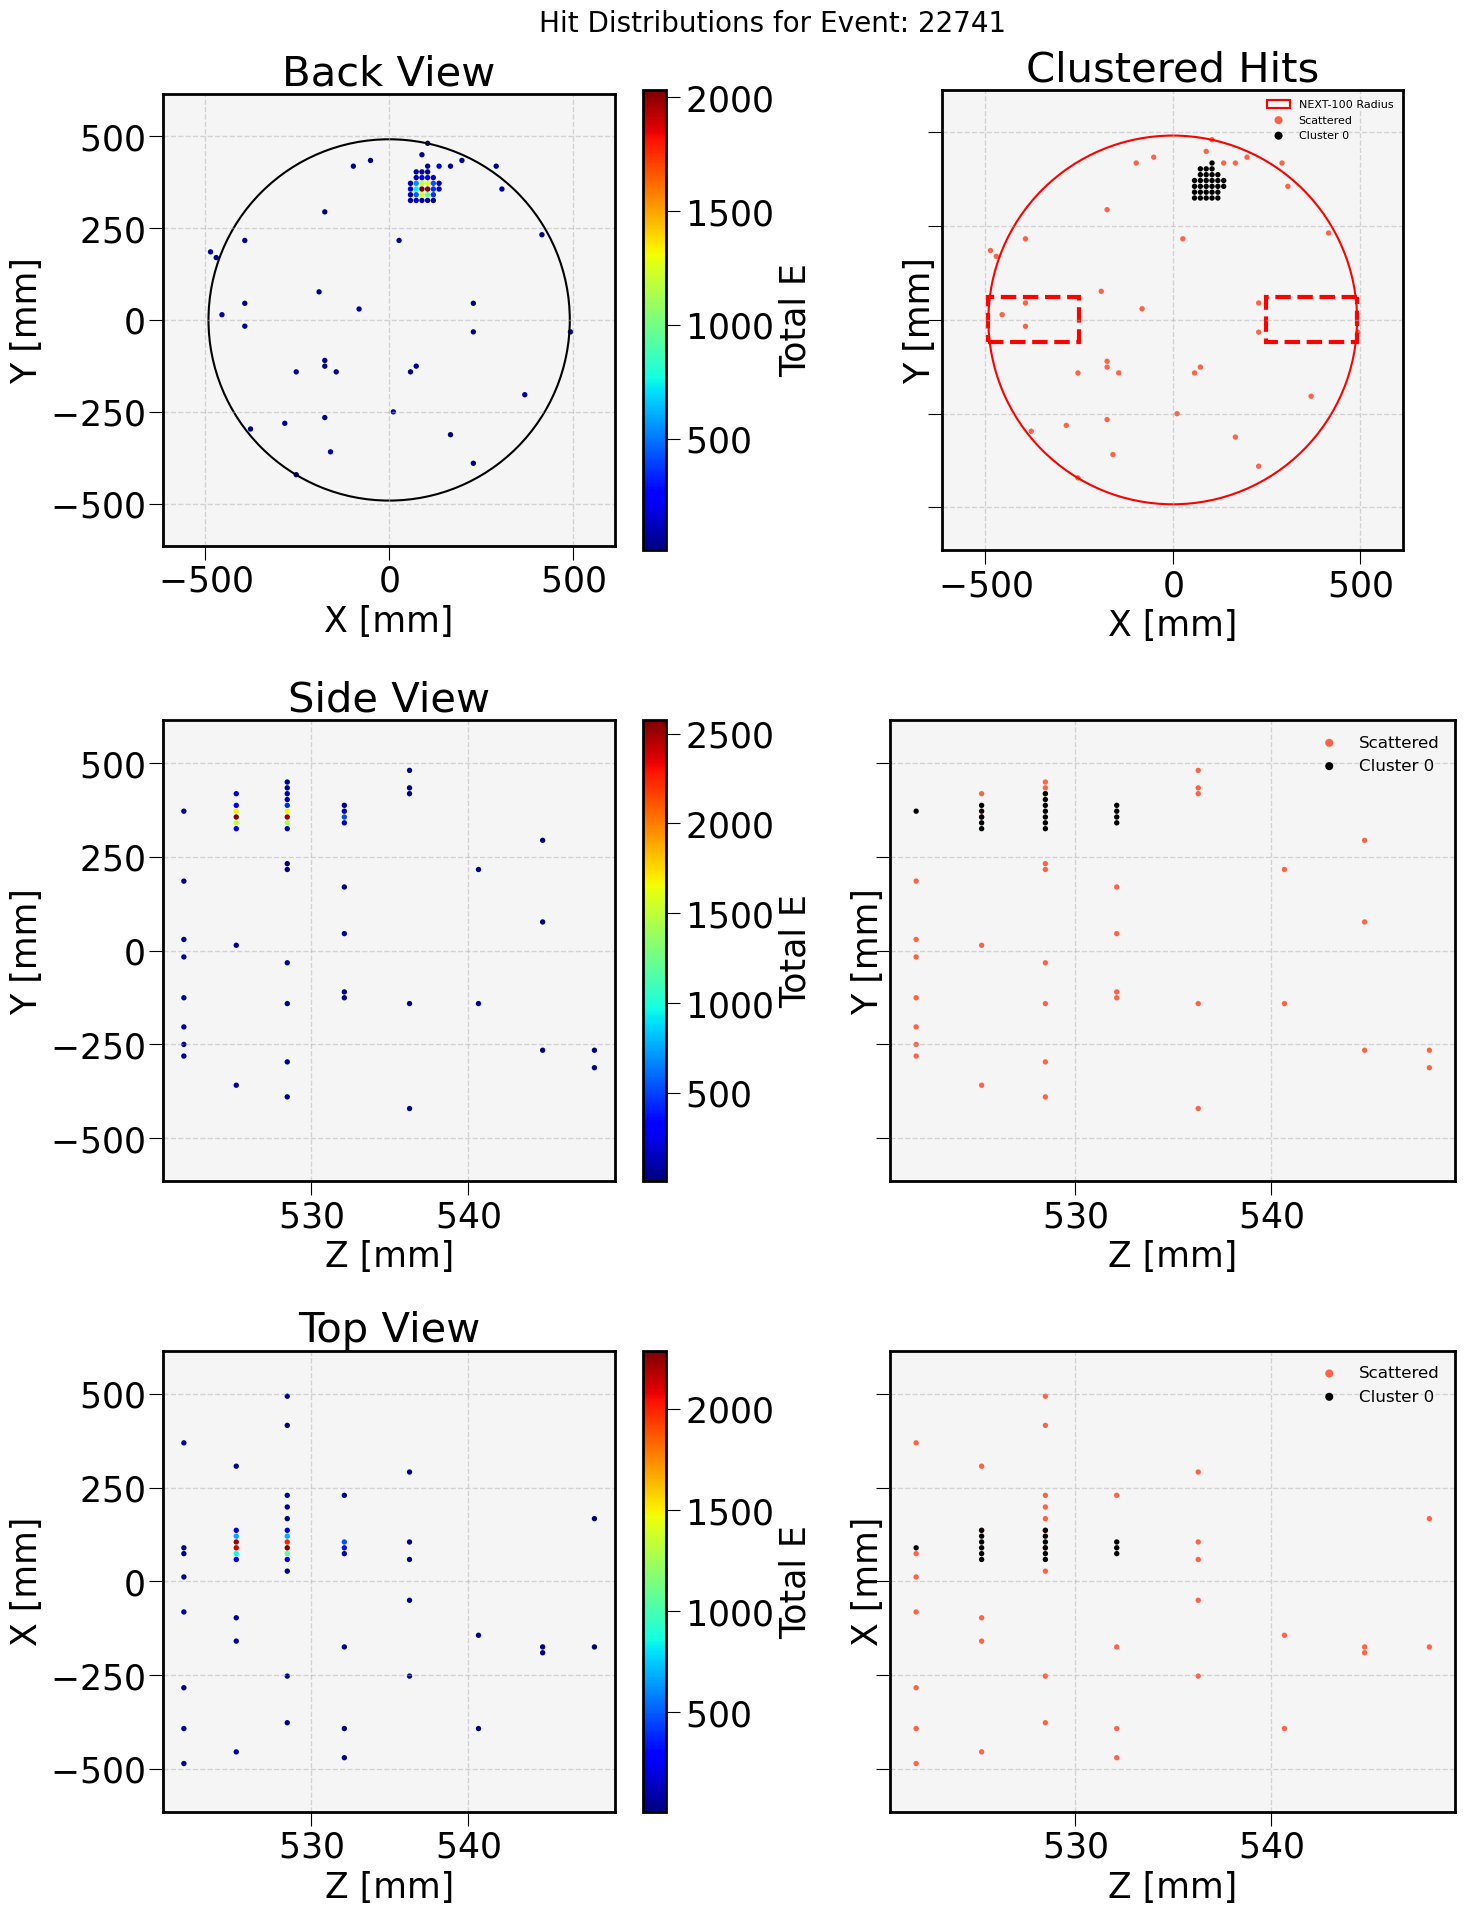

In [28]:
crudo.pt.display_event_cluster(plot_df, variable='E', event_column='global_event')

As you can see, we should first remove all the spurious hits to see the actual population in what we call _is_hole_ and _not_hole_

#### From Clean Sophronia

In [30]:
CLEAN_SOPH_DF = classify_hole_events(CLEAN_SOPH_DF, x_left, x_right, y_left, y_right)
CLEAN_SOPH_DF

,event,time,npeak,Xpeak,Ypeak,X,Y,Z,Q,E,...,run_id,global_event,E_hit_pe,R_sq,X_w,Y_w,Z_w,Z_bary,trapped,hole_tag
0,1,1.784798e+09,0,-151.147754,-314.290778,-175.125,-312.375,82.696125,6.805732,148.412477,...,16047,0,173.065791,128246.90625,-30308.146568,-54061.426319,14311.870248,84.312636,False,unclassified
1,1,1.784798e+09,0,-151.147754,-314.290778,-175.125,-296.825,82.696125,6.823937,148.809466,...,16047,0,173.528725,118773.84625,-30389.217989,-51507.663837,14350.153145,84.312636,False,unclassified
2,1,1.784798e+09,0,-151.147754,-314.290778,-159.575,-327.925,82.696125,18.723354,408.299841,...,16047,0,476.123950,132998.98625,-75977.479291,-156132.946241,39373.605669,84.312636,False,unclassified
3,1,1.784798e+09,0,-151.147754,-314.290778,-159.575,-312.375,82.696125,48.281818,1052.880719,...,16047,0,1227.778402,123042.32125,-195922.738538,-383527.278401,101532.516224,84.312636,False,unclassified
4,1,1.784798e+09,0,-151.147754,-314.290778,-159.575,-296.825,82.696125,14.036448,306.092551,...,16047,0,356.938651,113569.26125,-56958.485205,-105948.315031,29517.443286,84.312636,False,unclassified
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5344091,51758,1.784980e+09,0,-277.005257,163.356138,-315.075,169.675,537.579750,11.277419,50.285526,...,16057,83817,56.724038,128061.86125,-17872.326286,9624.651155,30493.694190,529.734375,False,unclassified
5344092,51758,1.784980e+09,0,-277.005257,163.356138,-299.525,138.575,537.579750,6.637702,29.597227,...,16057,83817,33.386829,108918.25625,-10000.189886,4626.579796,17948.083061,529.734375,False,unclassified
5344093,51758,1.784980e+09,0,-277.005257,163.356138,-299.525,169.675,537.579750,5.035139,22.451468,...,16057,83817,25.326133,118504.83125,-7585.810124,4297.211694,13614.816493,529.734375,False,unclassified
5344094,51758,1.784980e+09,0,-277.005257,163.356138,-268.425,169.675,537.579750,7.546556,33.649766,...,16057,83817,37.958251,100841.58625,-10188.943474,6440.566207,20405.586982,529.734375,False,unclassified


In [34]:
plot_df = CLEAN_SOPH_DF[CLEAN_SOPH_DF['hole_tag'] == 'is_hole']
print(f'Number of events: {plot_df.global_event.nunique()}')

Number of events: 3251


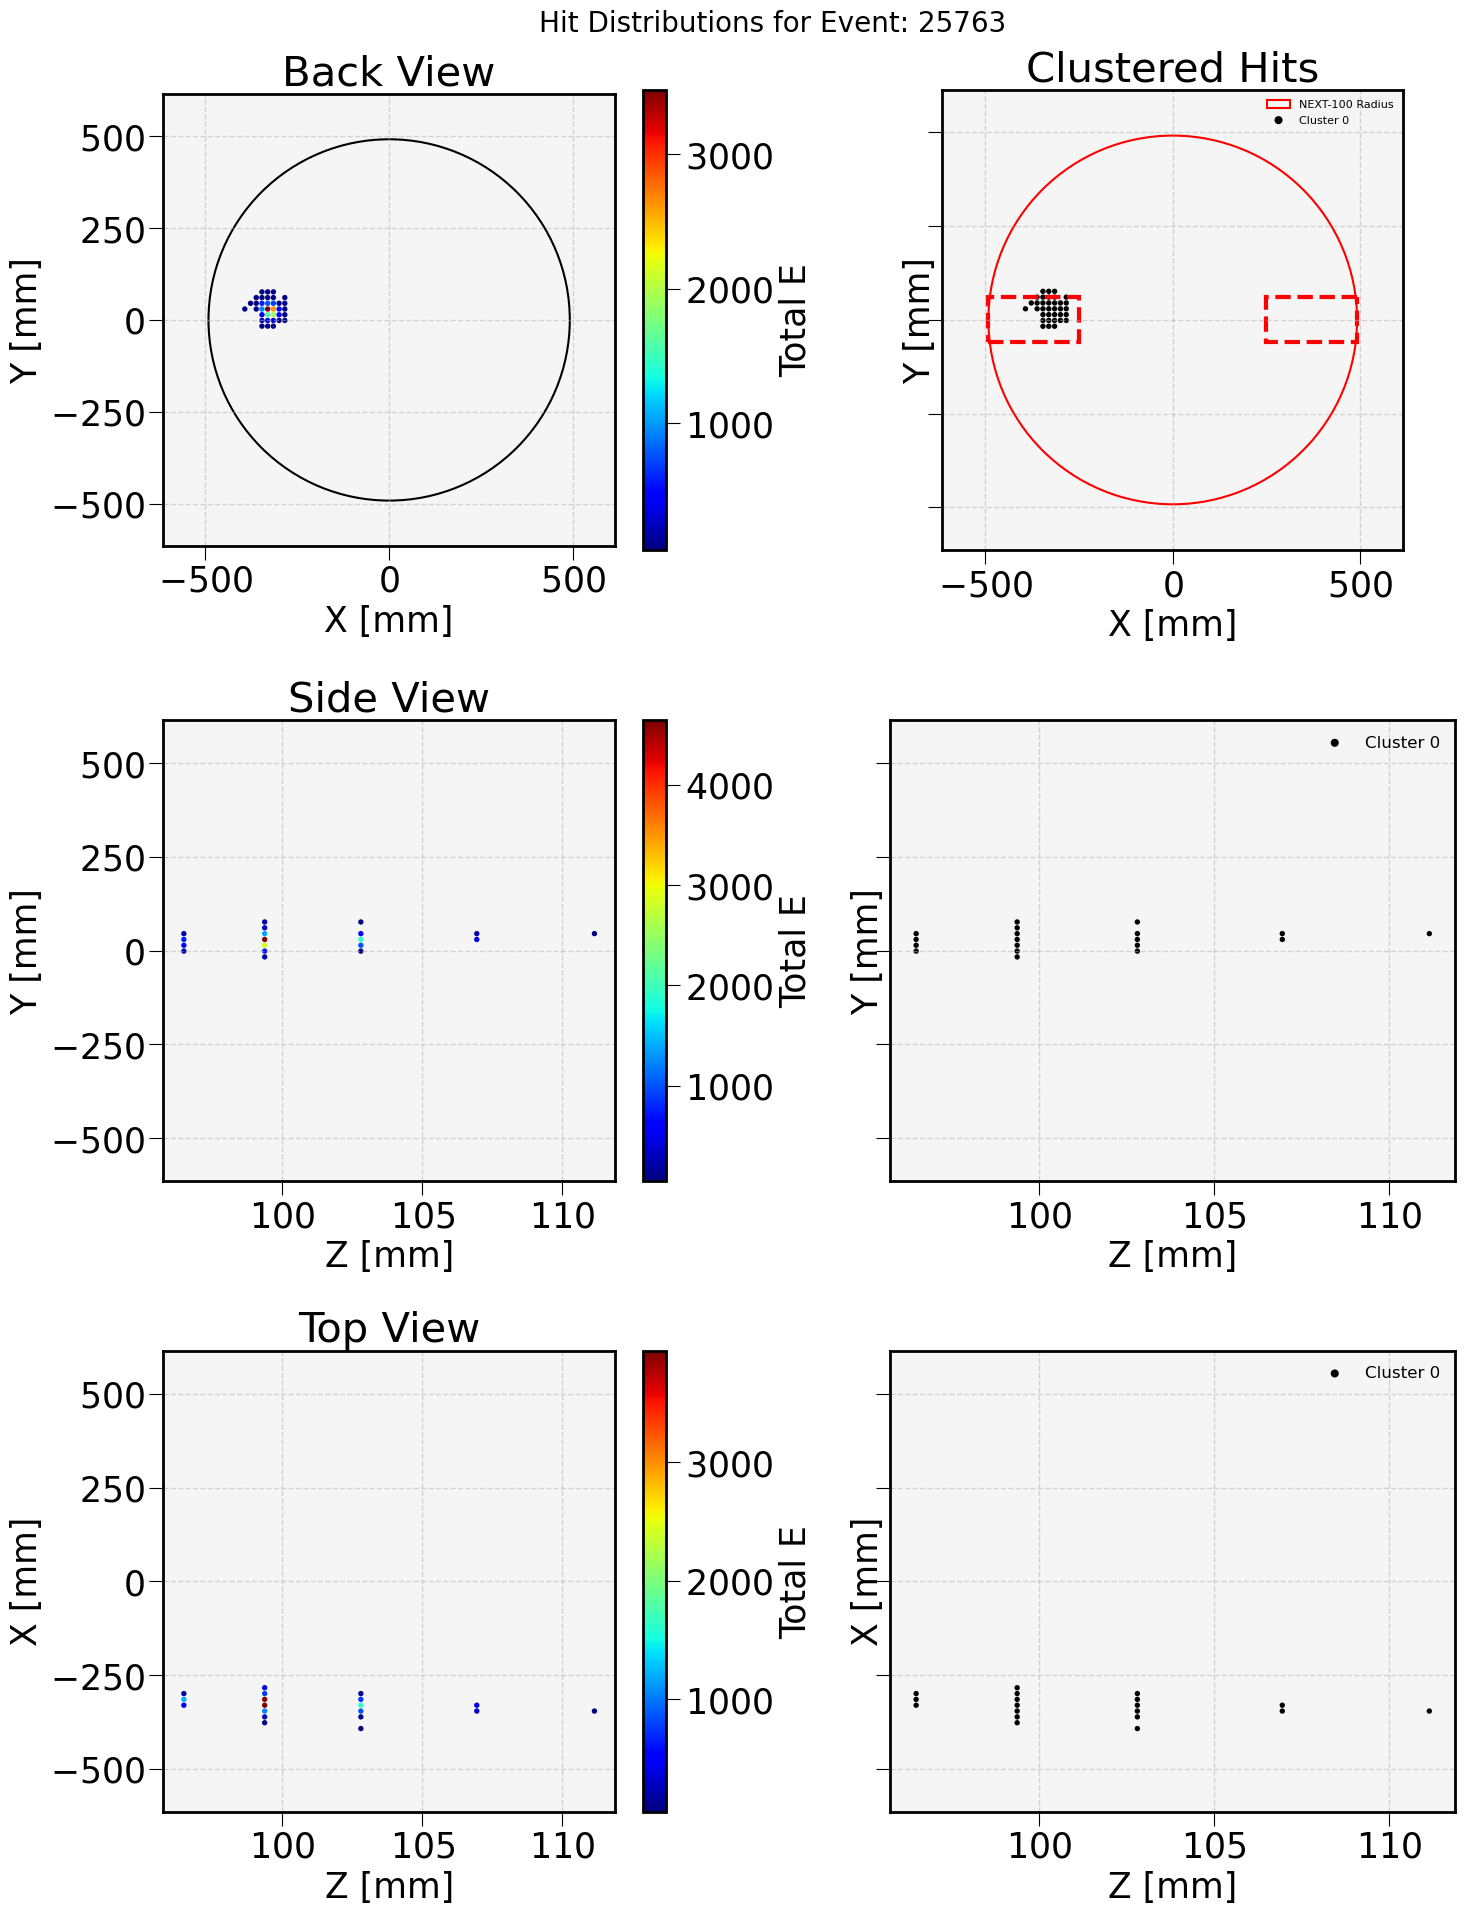

In [37]:
crudo.pt.display_event_cluster(plot_df, variable='E', event_column='global_event')

## Variables of Interest

In [64]:
# Construct a dorothea-based dataframe for comparisons
cols_to_add = ['hole_tag']

EVENT_INFO_DF = EVENT_INFO_DF.merge(CLEAN_SOPH_DF.groupby('global_event')[cols_to_add].first().reset_index(), on='global_event', how='left')
DORO_DF = DORO_DF.merge(EVENT_INFO_DF[['global_event', 'R_max', 'hole_tag']], on='global_event', how='left')

## Base Distributions

Bin edges: [250.     267.1875 284.375  301.5625 318.75   335.9375 353.125  370.3125
 387.5    404.6875 421.875  439.0625 456.25   473.4375 490.625  507.8125
 525.    ]
HOLE: R_max = [252.88, 492.52] mm
FULL: R_max = [260.28, 517.03] mm


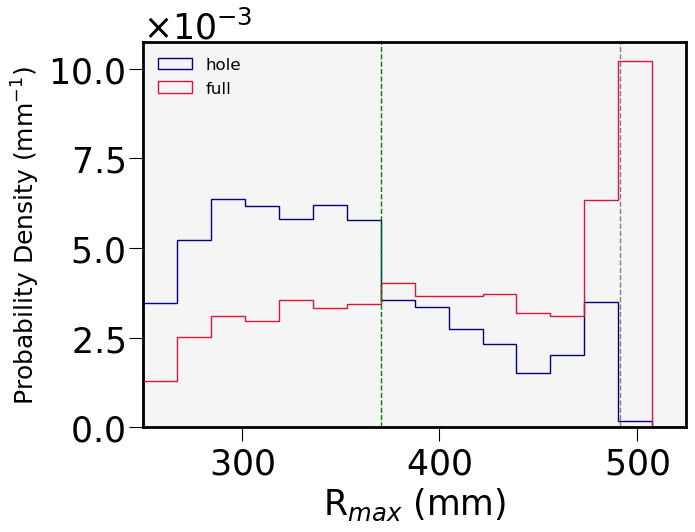

In [65]:
# Preliminary
bin_edges = np.linspace(250, 525, 17)
print(f"Bin edges: {bin_edges}")
colors = ['navy', 'crimson']

for (name, tag), color in zip(zip(['hole', 'full'], ['is_hole', 'not_hole']), colors):

    temp_df = DORO_DF[DORO_DF['hole_tag'] == tag]

    # Variables
    R_max = temp_df['R_max']
    DT    = temp_df['DT']

    # Masking
    mask = (DT >= 0) & (DT <= EXTRA_INFO['cath_lim'])
    R_max = R_max[mask]
    print(f"{name.upper()}: R_max = [{R_max.min():.2f}, {R_max.max():.2f}] mm")

    # Histogram
    counts, _, _ = plt.hist(R_max, bins=bin_edges, density=True, histtype='step', color=color, lw=1.0, label=name)

# Plot
plt.xlabel('R$_{max}$ (mm)')
plt.ylabel('Probability Density (mm$^{-1}$)', fontsize=18)
# plt.yscale('log')
plt.xlim(bin_edges[0], bin_edges[-1])
plt.ticklabel_format(axis='y', style='sci', scilimits=(-3, -3))
# Radial line
plt.axvline(x=370.312, c='green', ls='--', lw=1.0)
plt.axvline(x=crudo.pt.N100_rad, c='gray', ls='--', lw=1.0)

plt.legend(loc='upper left', facecolor='none', fontsize=12)
plt.gca().set_facecolor("whitesmoke")
plt.show()

HOLE: S1e = [21.61, 253.80] PE
FULL: S1e = [20.25, 263.78] PE


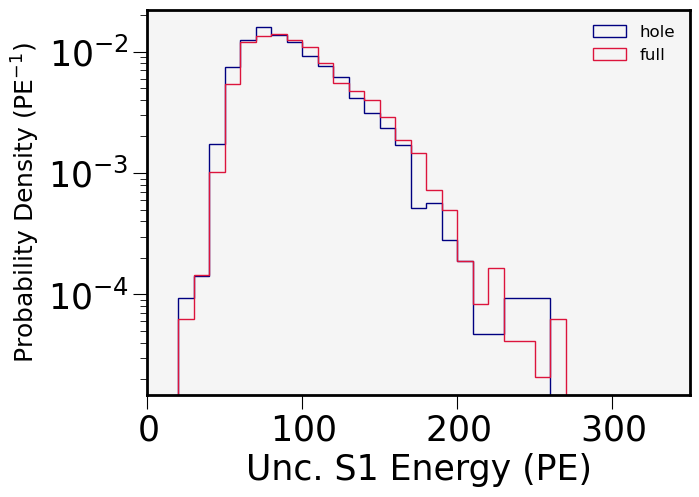

In [66]:
# Preliminary
bin_edges = np.linspace(0, 350, 36)
colors = ['navy', 'crimson']

for (name, tag), color in zip(zip(['hole', 'full'], ['is_hole', 'not_hole']), colors):

    temp_df = DORO_DF[DORO_DF['hole_tag'] == tag]

    # Variables
    S1e = temp_df['S1e']
    DT  = temp_df['DT']

    # Masking
    mask = (DT >= 0) & (DT <= EXTRA_INFO['cath_lim'])
    S1e = S1e[mask]
    print(f"{name.upper()}: S1e = [{S1e.min():.2f}, {S1e.max():.2f}] PE")

    # Histogram
    counts, _, _ = plt.hist(S1e, bins=bin_edges, density=True, histtype='step', color=color, lw=1.0, label=name)

# Plot
plt.xlabel('Unc. S1 Energy (PE)')
plt.ylabel('Probability Density (PE$^{-1}$)', fontsize=18)
plt.yscale('log')
plt.xlim(bin_edges[0], bin_edges[-1])
# plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

plt.legend(loc='upper right', facecolor='none', fontsize=12)
plt.gca().set_facecolor("whitesmoke")
plt.show()

HOLE: S2e = [4949.88, 33567.73] PE
FULL: S2e = [2519.72, 31449.88] PE


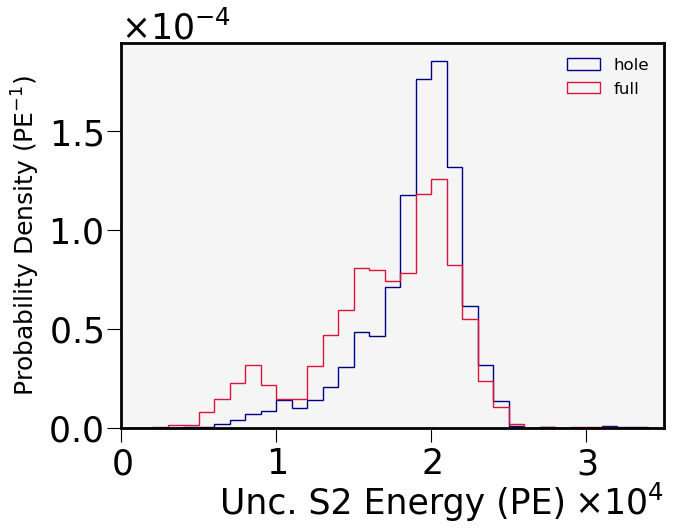

In [67]:
# Preliminary
bin_edges = np.linspace(0, 35e3, 36)
colors = ['navy', 'crimson']

for (name, tag), color in zip(zip(['hole', 'full'], ['is_hole', 'not_hole']), colors):

    temp_df = DORO_DF[DORO_DF['hole_tag'] == tag]

    # Variables
    S2e = temp_df['S2e']
    DT  = temp_df['DT']

    # Masking
    mask = (DT >= 0) & (DT <= EXTRA_INFO['cath_lim'])
    S2e = S2e[mask]
    print(f"{name.upper()}: S2e = [{S2e.min():.2f}, {S2e.max():.2f}] PE")

    # Histogram
    counts, _, _ = plt.hist(S2e, bins=bin_edges, density=True, histtype='step', color=color, lw=1.0, label=name)

# Plot
plt.xlabel('Unc. S2 Energy (PE)')
plt.ylabel('Probability Density (PE$^{-1}$)', fontsize=18)
# plt.yscale('log')
plt.xlim(bin_edges[0], bin_edges[-1])
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

plt.legend(loc='upper right', facecolor='none', fontsize=12)
plt.gca().set_facecolor("whitesmoke")
plt.show()

## Energy Corrections

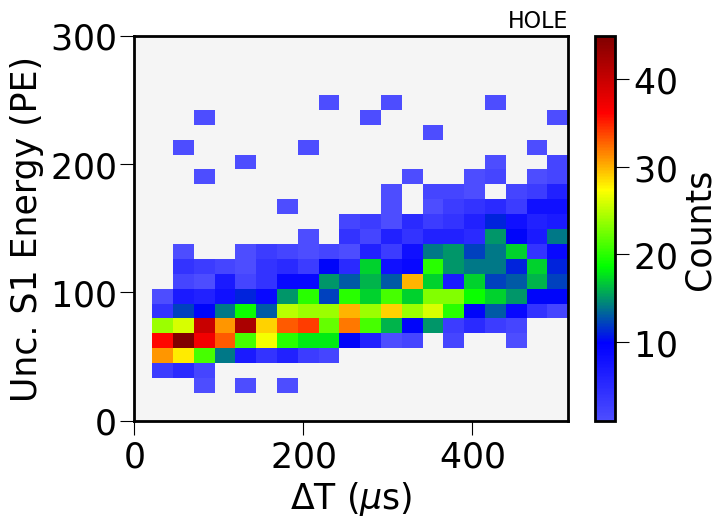

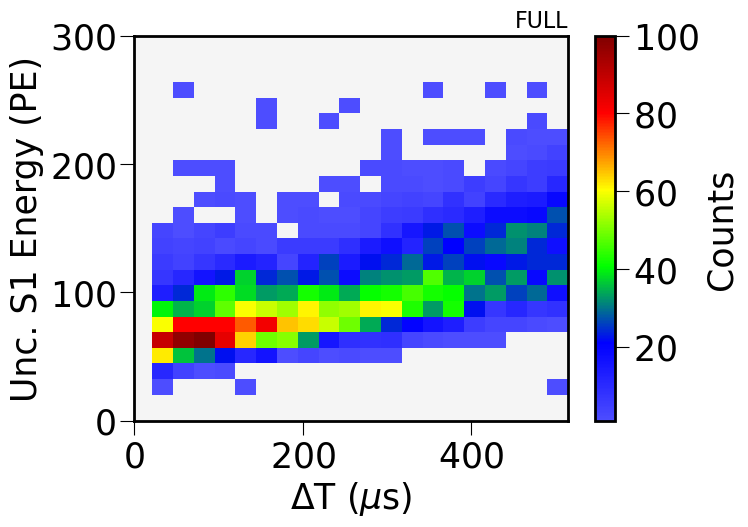

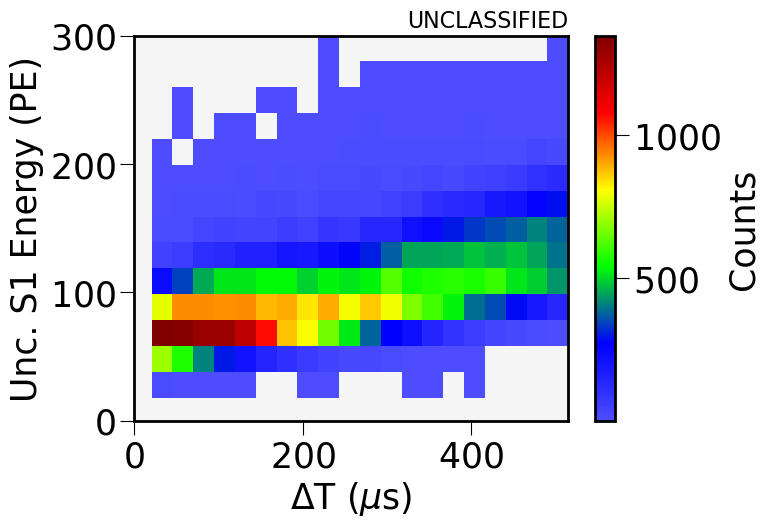

In [68]:
for name, tag in zip(['hole', 'full', 'unclassified'], ['is_hole', 'not_hole', 'unclassified']):

    temp_df = DORO_DF[DORO_DF['hole_tag'] == tag]

    # Variables
    S1e = temp_df['S1e']
    DT  = temp_df['DT']

    # Masking
    mask = (DT >= 0) & (DT <= EXTRA_INFO['cath_lim'])
    S1e_mask = S1e[mask]
    DT_mask  = DT[mask]

    # 2D Histogram
    s1e_dt_map, ex, ey = np.histogram2d(DT_mask, S1e_mask, bins=[20, 20])
    s1e_dt_map         = np.ma.masked_where(s1e_dt_map==0, s1e_dt_map)

    # Plot
    plt.pcolormesh(ex, ey, s1e_dt_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    plt.colorbar(label='Counts')
    plt.xlabel('$\Delta$T ($\mu$s)')
    plt.xlim(0, DT_mask.max())
    plt.ylim(0, 300)
    plt.ylabel('Unc. S1 Energy (PE)')
    plt.title(f'{name.upper()}', loc='right', fontsize=16)

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

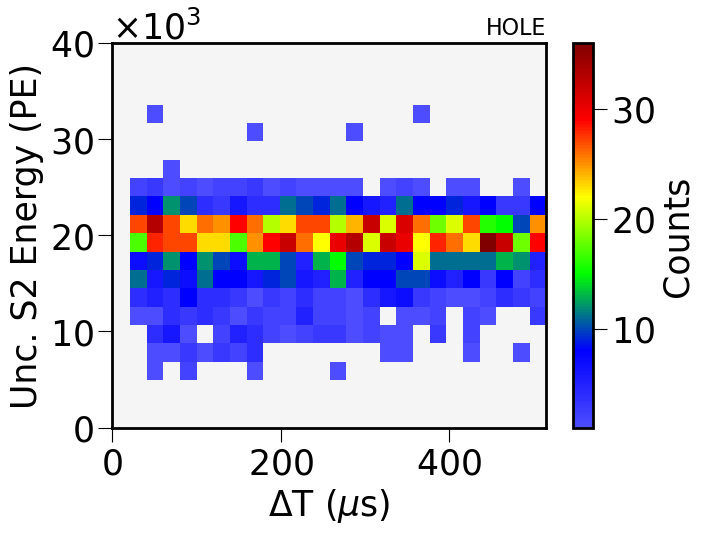

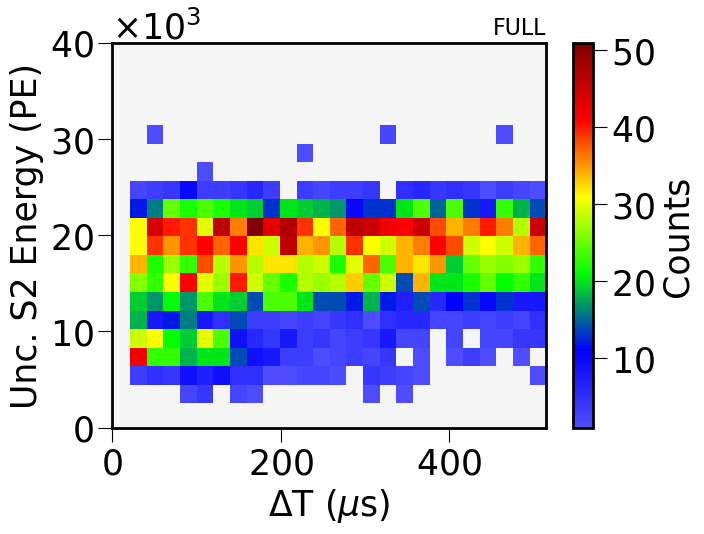

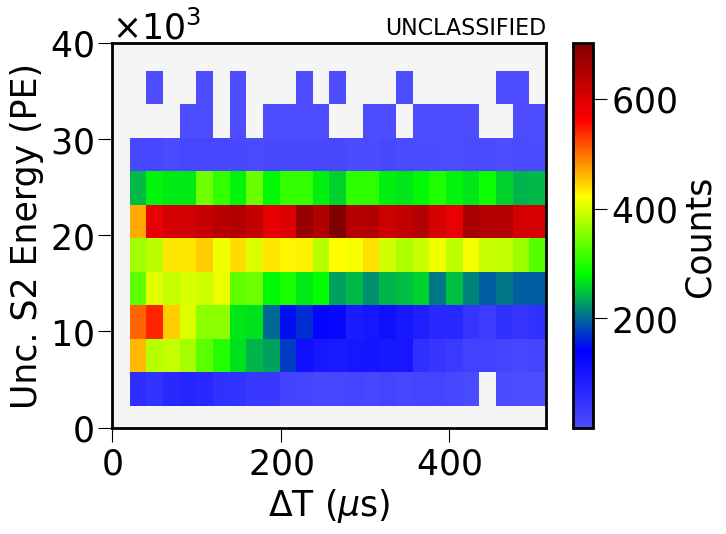

In [69]:
for name, tag in zip(['hole', 'full', 'unclassified'], ['is_hole', 'not_hole', 'unclassified']):

    temp_df = DORO_DF[DORO_DF['hole_tag'] == tag]

    # Variables
    S2e = temp_df['S2e']
    DT = temp_df['DT']

    # Masking
    mask = (DT >= 0) & (DT <= EXTRA_INFO['cath_lim'])
    S2e_mask = S2e[mask]
    DT_mask = DT[mask]

    # 2D Histogram
    s2e_dt_map, ex, ey = np.histogram2d(DT_mask, S2e_mask, bins=[25, 15])
    s2e_dt_map         = np.ma.masked_where(s2e_dt_map==0, s2e_dt_map)

    # Plot
    plt.pcolormesh(ex, ey, s2e_dt_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    plt.colorbar(label='Counts')
    plt.xlabel('$\Delta$T ($\mu$s)')
    plt.xlim(0, DT_mask.max())
    plt.ylim(0, 40e3)
    plt.ylabel('Unc. S2 Energy (PE)')
    plt.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
    plt.title(f'{name.upper()}', loc='right', fontsize=16)

    # Lines
    # plt.axvline(x=150, c='red', ls='--')
    # plt.axhline(y=12e3, c='red', ls='--')

    plt.gca().set_facecolor("whitesmoke")
    plt.show()

# Lifetime

Zone 0 | R = [0, 150) mm
Fit: N0 = (24045.80 ± 41.05) PE, τ = (34.14 ± 6.40) ms
     χ² / ndof = 1.6331


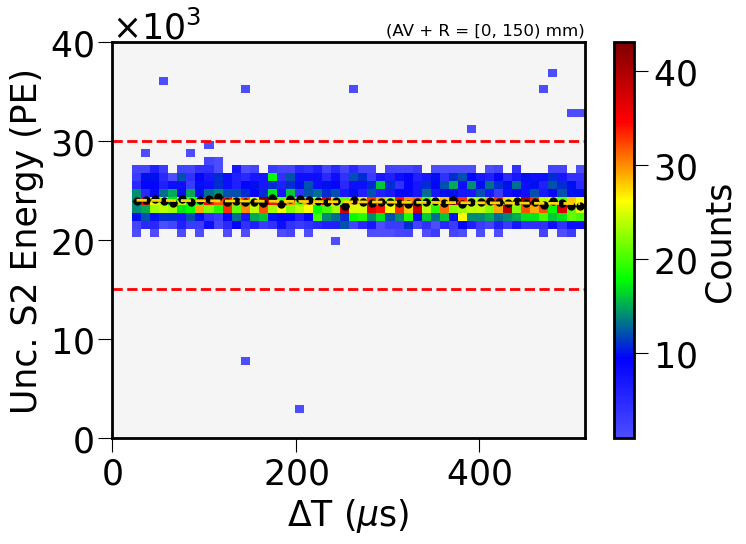

Zone 1 | R = [150, 300) mm
Fit: N0 = (21999.15 ± 32.48) PE, τ = (33.25 ± 5.35) ms
     χ² / ndof = 1.1039


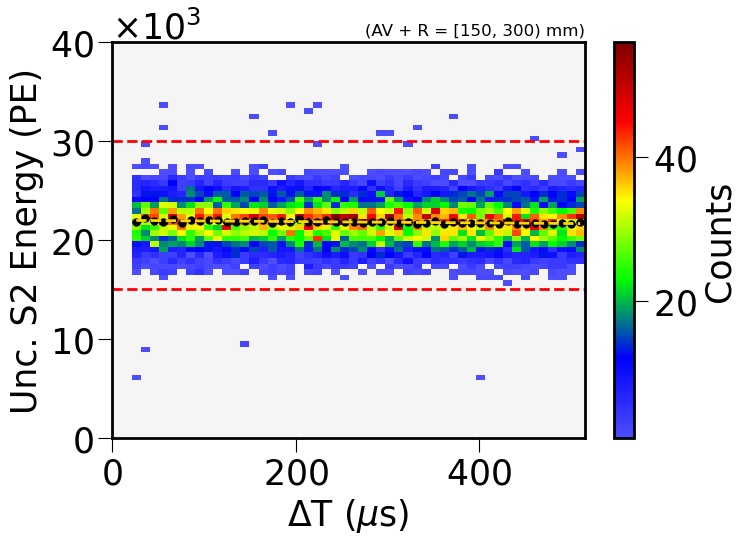

Zone 2 | R = [300, 450) mm
Fit: N0 = (17350.48 ± 43.29) PE, τ = (37.75 ± 11.99) ms
     χ² / ndof = 7.1787


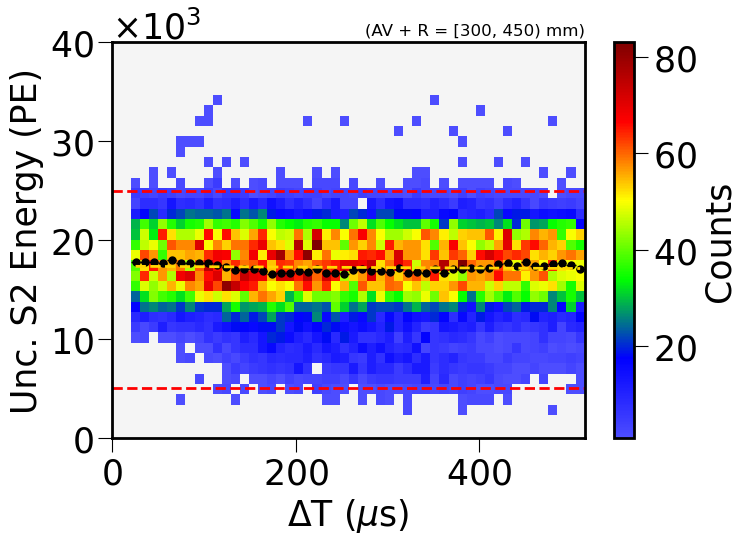

Zone 3 | R = [450, 500) mm
Fit: N0 = (9734.02 ± 43.93) PE, τ = (10.18 ± 3.18) ms
     χ² / ndof = 2.8479


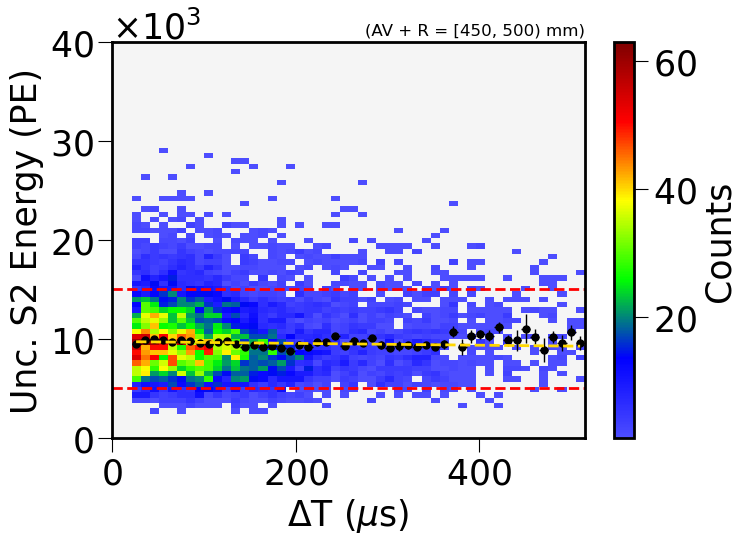

In [ ]:
# Global
n_bins  = 50
rad_lim = [150, 300, 450, 500]
DORO_DF['lifetime'] = np.zeros_like(DORO_DF['S2e'])

# Use exponential decay function with b = 0
def exp_bfixed(x, N0, tau):
    return crudo.ff.exponential_decay(x, N0, tau, 0)

for i, r_lim in enumerate(rad_lim):

    if i == 0: r_min = 0
    else:      r_min = rad_lim[i-1]

    print(f"Zone {i} | R = [{r_min}, {r_lim}) mm")
        
    # Variables    
    E2 = DORO_DF['S2e']
    DT = DORO_DF['DT']
    R  = DORO_DF['R']

    # Masking
    mask = EXTRA_INFO['AV_Z_mask'] & (R >= r_min) & (R < r_lim)
    E2_mask  = E2[mask]
    DT_mask  = DT[mask]

    # Preliminary
    DT_down = DT_mask.min();    DT_up = DT_mask.max()
    E2_down = 15e3;  E2_up = 30e3
    if i == 2:  E2_down = 5e3; E2_up = 25e3
    elif i == 3:  E2_down = 5e3; E2_up = 15e3

    # 2D histogram: normalized by corrected DAQ data taking time
    S2e_DT_map, ex, ey = np.histogram2d(DT_mask, E2_mask, bins=[50, 50])                        
    S2e_DT_map         = np.ma.masked_where(S2e_DT_map==0, S2e_DT_map)
    
    # ---- Exponential Fit ----- #
    # Filter the data for the fit
    fit_region_mask = (DT_mask >= DT_down) & (DT_mask <= DT_up) & \
                    (E2_mask >= E2_down) & (E2_mask <= E2_up)
    DT_fit = DT_mask[fit_region_mask]
    E2_fit = E2_mask[fit_region_mask]

    # Compute representative values for the fit
    DT_centers, DT_errors, S2e_means, S2e_errors = crudo.ff.prefit_2D(DT_fit, E2_fit, bins=ex)
    # Filter out points with zero error (bins with 1 event)
    valid_points = S2e_errors > 0
    DT_centers = DT_centers[valid_points];      DT_errors  = DT_errors[valid_points]
    S2e_means  = S2e_means[valid_points];       S2e_errors = S2e_errors[valid_points]

    # Definte the cost function + initial guess
    least_squares = LeastSquares(DT_centers, S2e_means, S2e_errors, exp_bfixed)
    init_guess = [S2e_means.max(), (DT_centers.max() - DT_centers.min()) / 2]
    # print(f'\nInitial guess: N0 = {init_guess[0]:.4f} PE, tau = {init_guess[1]:.4f} μs')

    # Define the Minuit object
    m = Minuit(least_squares, *init_guess)

    # Minimization process of the cost function and error estimation
    m.migrad()
    m.hesse()

    # Results
    popt = m.values;  perr = m.errors
    print(f'Fit: N0 = ({popt[0]:.2f} ± {perr[0]:.2f}) PE, τ = ({popt[1] / 1e3:.2f} ± {perr[1] / 1e3:.2f}) ms')
    # FIT_PARAMETERS[key]["S2e"] = {"N0_CV": popt[0], "N0_err": perr[0], "tau_CV": popt[1], "tau_err": perr[1]}
    
    # Reduced chi-square
    chi2 = m.fval
    ndof = len(DT_centers) - m.nfit
    print(f"     χ² / ndof = {chi2 / ndof:.4f}")

    # ----- Plotting ----- #
    plt.figure(figsize=(8, 6))
    # Data
    plt.pcolormesh(ex, ey, S2e_DT_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
    cbar = plt.colorbar(label='Counts', shrink=1.0)
    # cbar.formatter.set_powerlimits((-3, -3))

    # Fit
    fit_y = exp_bfixed(DT_centers, *popt)
    plt.errorbar(DT_centers, S2e_means, xerr=DT_errors, yerr=S2e_errors, fmt='o', c='black', ecolor='black', lw=1.0, markersize=5)
    plt.plot(DT_centers, fit_y, c='gold', ls='--', zorder=3)
    # plt.axvline(x=DT_down, c='red', ls='--')
    plt.axhline(y=E2_down, c='red', ls='--')
    plt.axhline(y=E2_up, c='red', ls='--')

    # ----- Styling ----- #
    plt.xlabel('$\Delta$T ($\mu$s)')
    plt.xlim(0, DT_mask.max())
    plt.ylabel('Unc. S2 Energy (PE)') 
    plt.ylim(0, 40e3)
    plt.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
    plt.title(f'(AV + R = [{r_min}, {r_lim}) mm)', fontsize=12, loc='right')

    plt.gca().set_facecolor("whitesmoke")
    plt.tight_layout()
    plt.show() 

In [155]:
DORO_DF

,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,X,Y,R,Phi,Xrms,Yrms,run_id,global_event,trapped,lifetime
0,1,1.784798e+09,0,0,1,1,375.0,9.748066,76.116409,1518450.0,...,-151.147754,-314.290778,348.746809,-2.019061,12.225466,13.285127,16047,0,False,0.0
1,8,1.784798e+09,0,0,1,1,1075.0,18.987965,156.188171,1075200.0,...,110.144318,337.879085,355.378737,1.255672,13.369742,12.333677,16047,1,True,0.0
2,15,1.784798e+09,0,0,1,1,300.0,13.149719,89.383507,1236075.0,...,12.438813,-27.992375,30.631636,-1.152639,13.982804,14.571225,16047,2,False,0.0
3,29,1.784798e+09,0,0,1,1,1150.0,19.960472,186.114441,1077475.0,...,-161.245239,-207.862581,263.072005,-2.230562,16.436524,14.778878,16047,3,False,0.0
4,36,1.784798e+09,0,0,1,1,350.0,14.803468,109.077393,1077725.0,...,-100.956162,-38.659718,108.105136,-2.775883,14.790812,15.515636,16047,4,False,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83814,51716,1.784980e+09,0,0,1,1,575.0,19.112818,120.796349,1077500.0,...,240.799452,80.398562,253.866707,0.322244,51.051457,29.569447,16057,83814,False,0.0
83815,51730,1.784980e+09,0,0,1,1,2125.0,21.479023,266.143982,1078825.0,...,-27.427228,-58.695773,64.787705,-2.007925,51.645186,42.128288,16057,83815,False,0.0
83816,51737,1.784980e+09,0,0,1,1,400.0,10.611453,75.582512,1288700.0,...,-255.542047,31.835407,257.517438,3.017651,24.388219,37.667702,16057,83816,False,0.0
83817,51751,1.784980e+09,0,0,1,1,300.0,13.802027,99.195099,1075900.0,...,20.465066,-417.275985,417.777532,-1.521791,13.184129,13.580263,16057,83817,False,0.0


Processing: QI & R = [0, 150) mm
Fit: N0 = (24092.13 ± 78.66) PE, τ = (51.06 ± 27.29) ms
     χ² / ndof = 1.2032


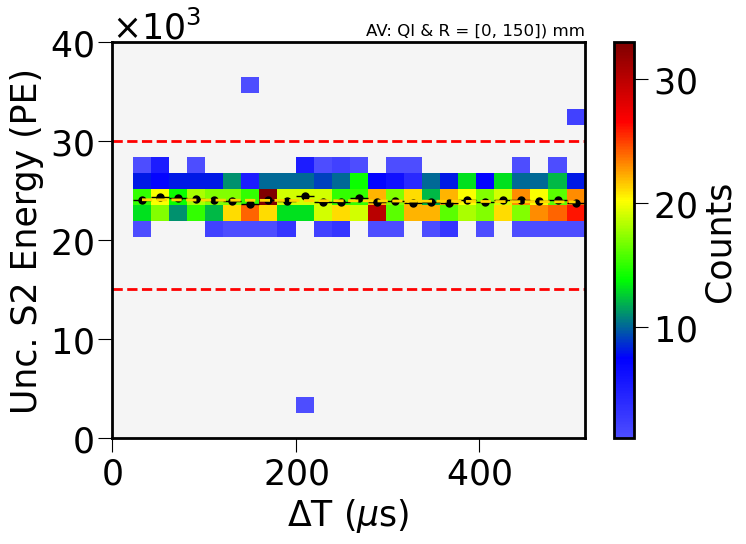

Processing: QI & R = [150, 300) mm
Fit: N0 = (22213.02 ± 53.69) PE, τ = (23.74 ± 4.51) ms
     χ² / ndof = 0.5346


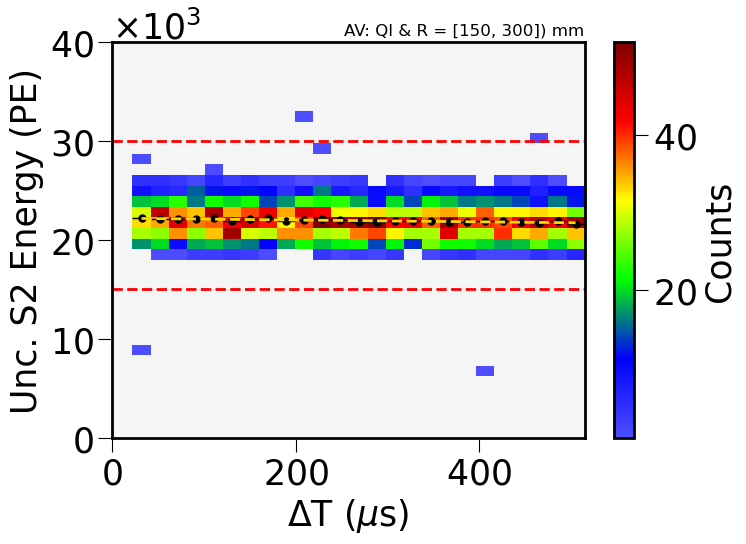

Processing: QI & R = [300, 450) mm
Fit: N0 = (17169.42 ± 59.36) PE, τ = (13.09 ± 2.09) ms
     χ² / ndof = 6.9745


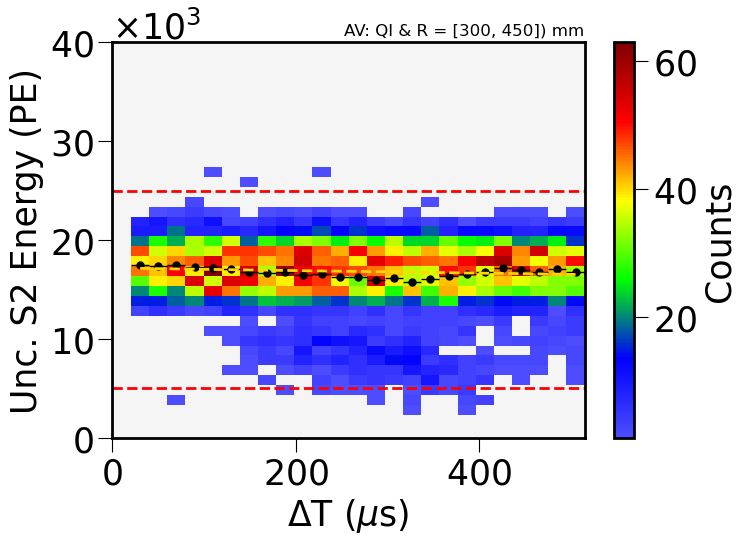

Processing: QI & R = [450, 500) mm
Fit: N0 = (9741.84 ± 66.26) PE, τ = (3.22 ± 0.50) ms
     χ² / ndof = 5.0586


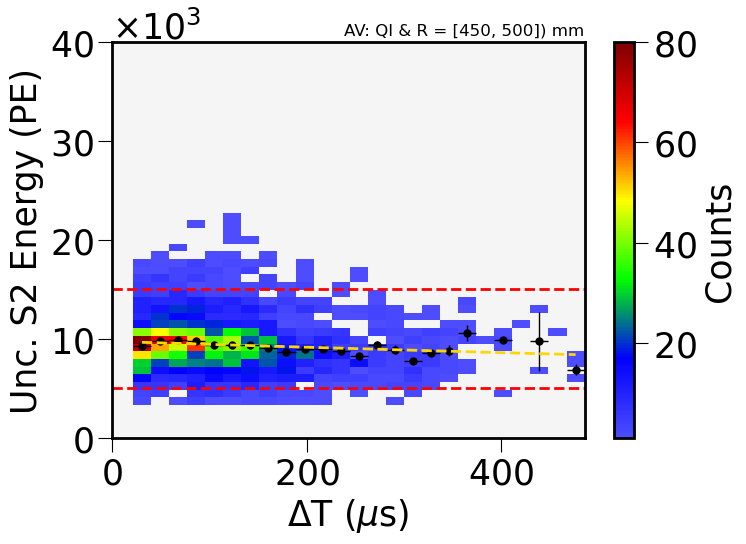

Processing: QII & R = [0, 150) mm
Fit: N0 = (23972.40 ± 76.72) PE, τ = (272.16 ± 758.35) ms
     χ² / ndof = 1.1471


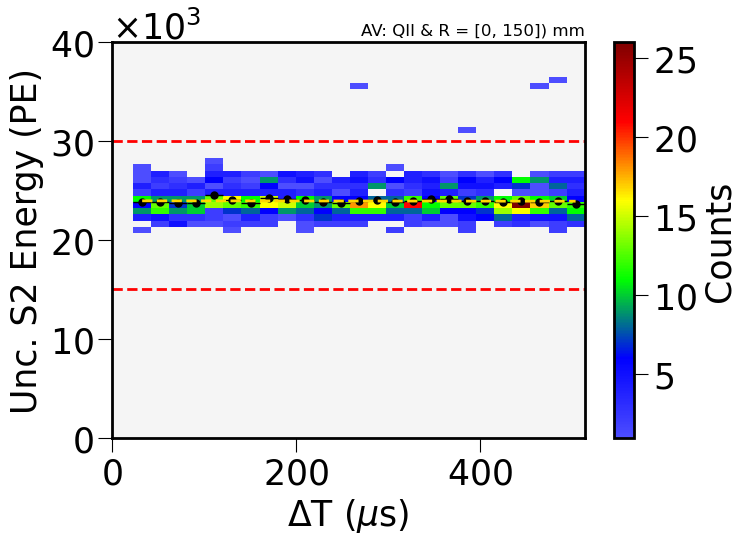

Processing: QII & R = [150, 300) mm
Fit: N0 = (23172.35 ± 58.75) PE, τ = (24.89 ± 5.28) ms
     χ² / ndof = 0.8054


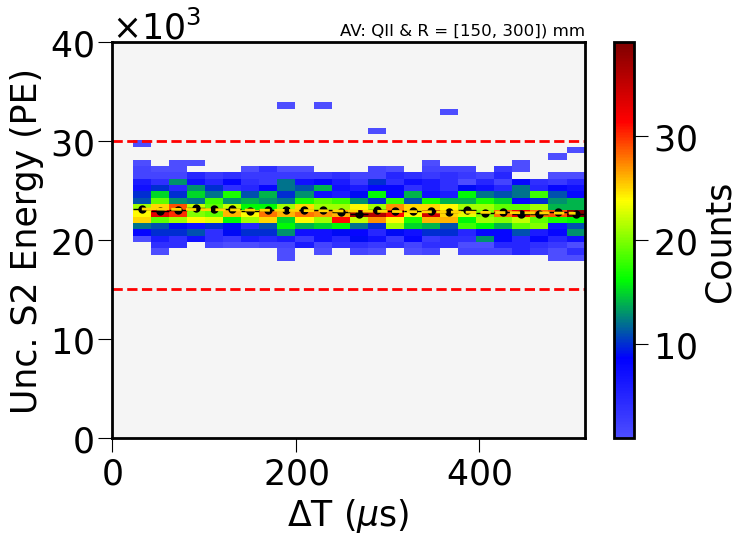

Processing: QII & R = [300, 450) mm
Fit: N0 = (19478.69 ± 90.43) PE, τ = (13.93 ± 3.22) ms
     χ² / ndof = 25.9192


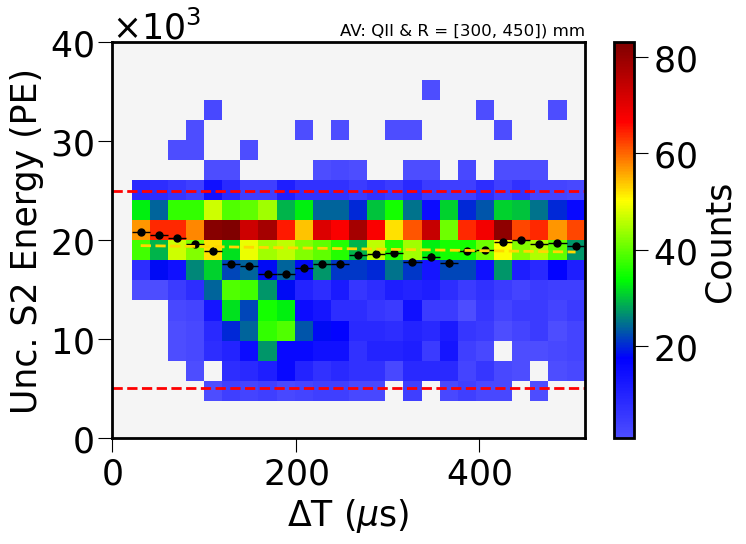

Processing: QII & R = [450, 500) mm
Fit: N0 = (12161.87 ± 138.99) PE, τ = (0.89 ± 0.10) ms
     χ² / ndof = 5.2498


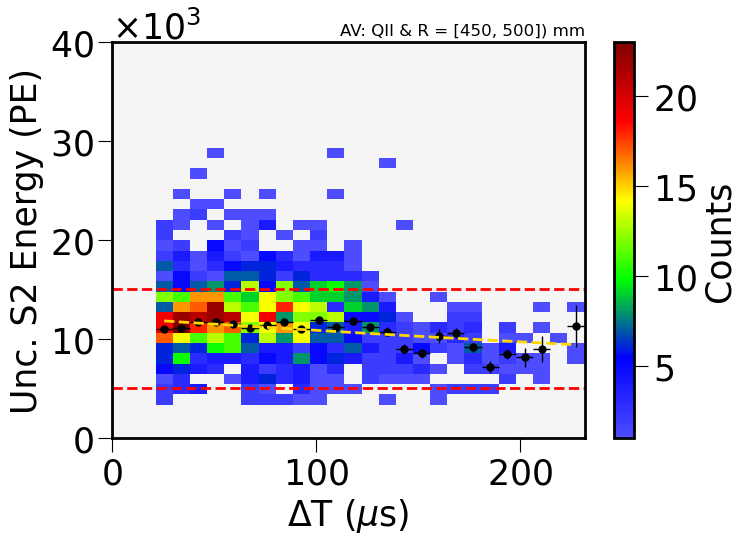

Processing: QIII & R = [0, 150) mm
Fit: N0 = (23811.70 ± 86.54) PE, τ = (19.43 ± 4.45) ms
     χ² / ndof = 1.3510


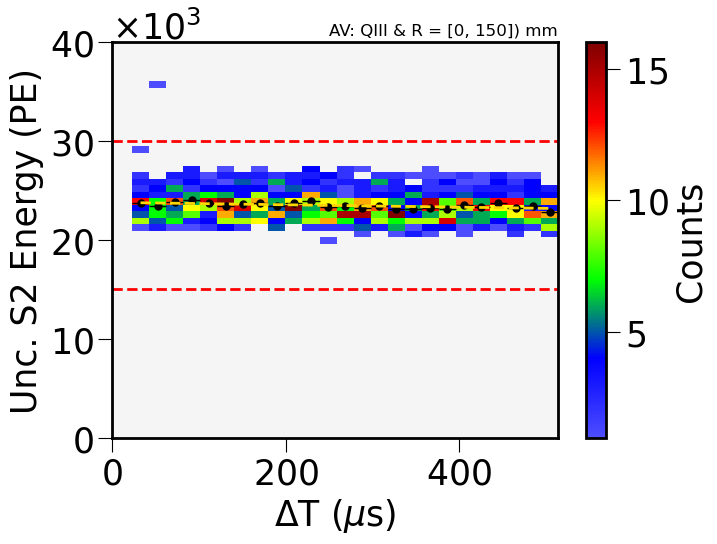

Processing: QIII & R = [150, 300) mm
Fit: N0 = (20465.93 ± 58.73) PE, τ = (49.86 ± 23.45) ms
     χ² / ndof = 1.1966


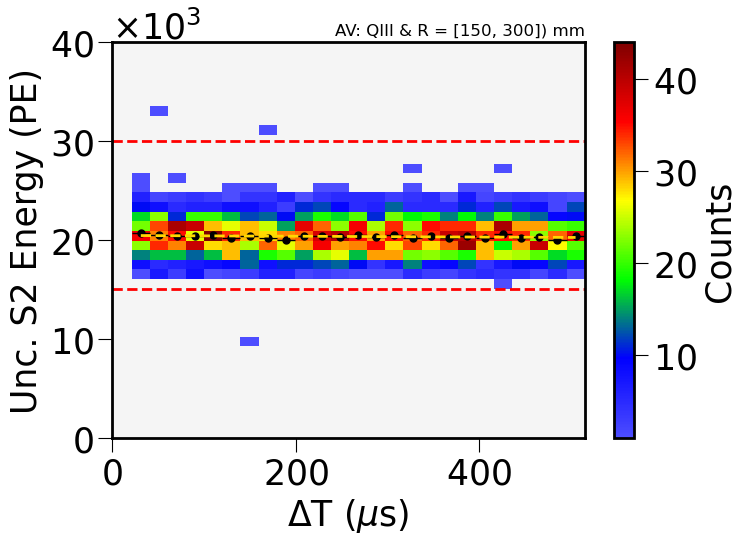

Processing: QIII & R = [300, 450) mm
Fit: N0 = (15153.83 ± 66.54) PE, τ = (33.39 ± 16.87) ms
     χ² / ndof = 2.3008


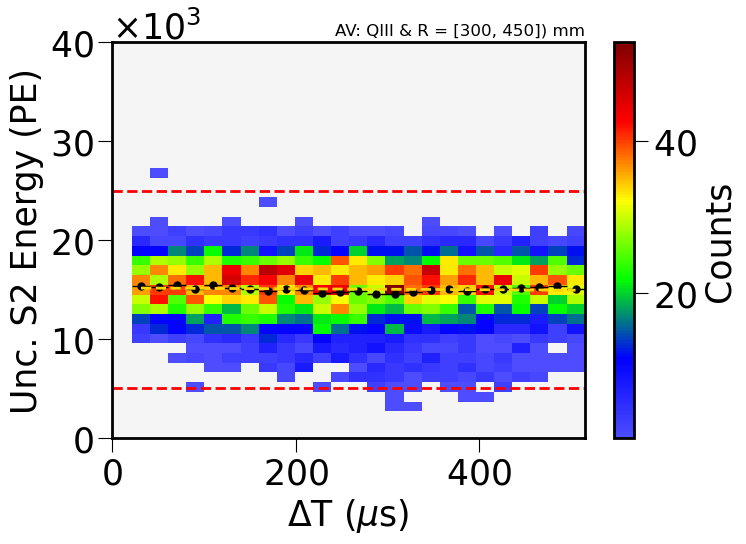

Processing: QIII & R = [450, 500) mm
Fit: N0 = (8529.75 ± 46.57) PE, τ = (38411.53 ± 617664.61) ms
     χ² / ndof = 2.2970


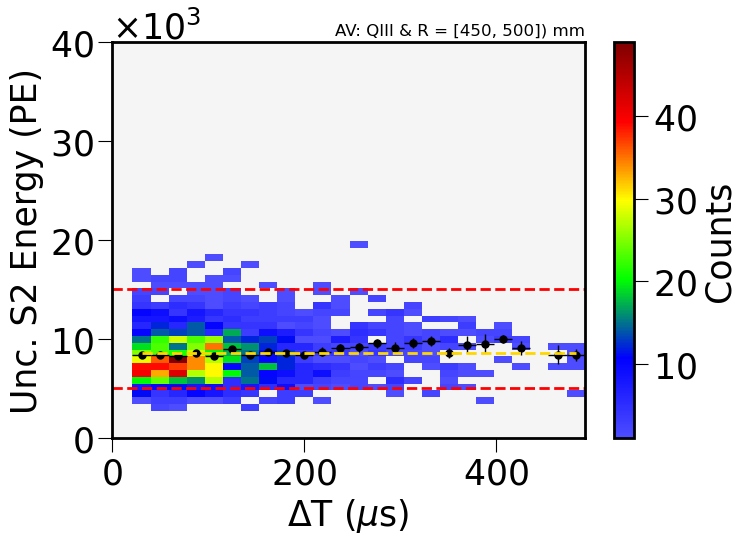

Processing: QIV & R = [0, 150) mm
Fit: N0 = (24367.82 ± 83.73) PE, τ = (19.24 ± 4.09) ms
     χ² / ndof = 0.6467


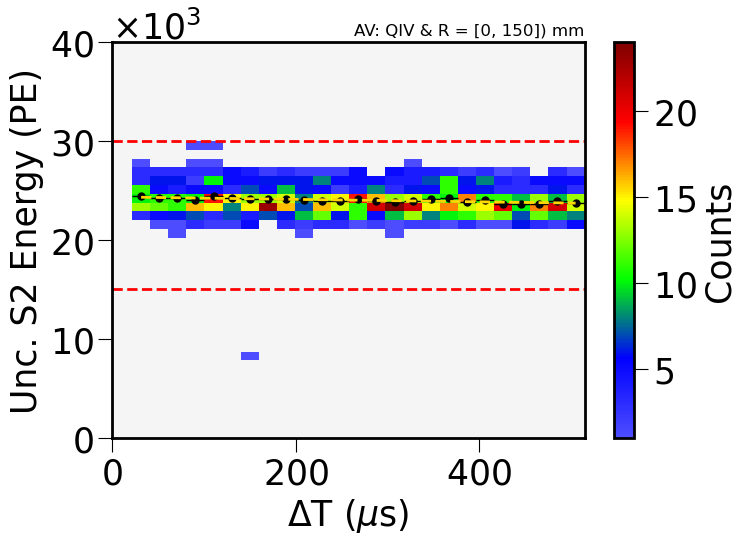

Processing: QIV & R = [150, 300) mm
Fit: N0 = (22219.26 ± 53.91) PE, τ = (43.58 ± 14.93) ms
     χ² / ndof = 1.0235


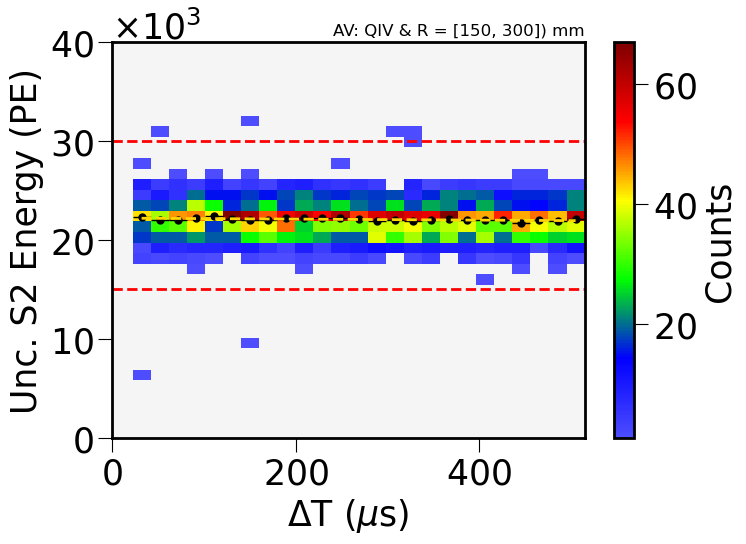

Processing: QIV & R = [300, 450) mm
Fit: N0 = (18833.95 ± 71.79) PE, τ = (27.86 ± 10.04) ms
     χ² / ndof = 0.8470


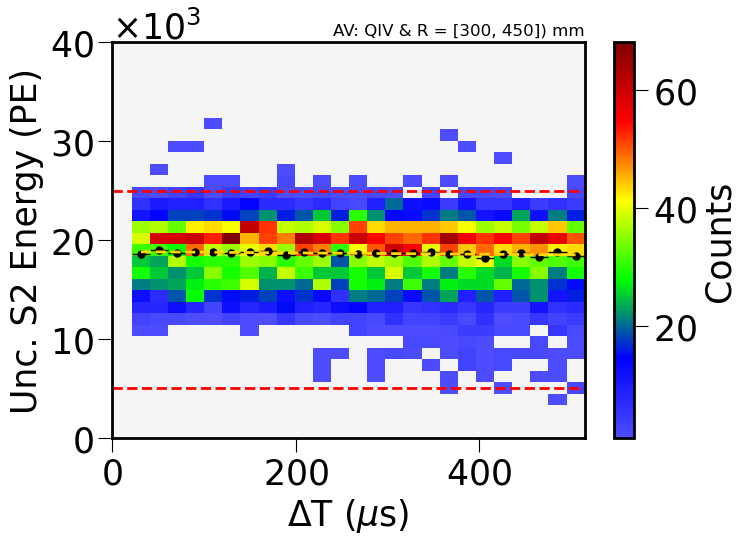

Processing: QIV & R = [450, 500) mm
Fit: N0 = (9937.53 ± 47.26) PE, τ = (10573.48 ± 207752.17) ms
     χ² / ndof = 1.3448


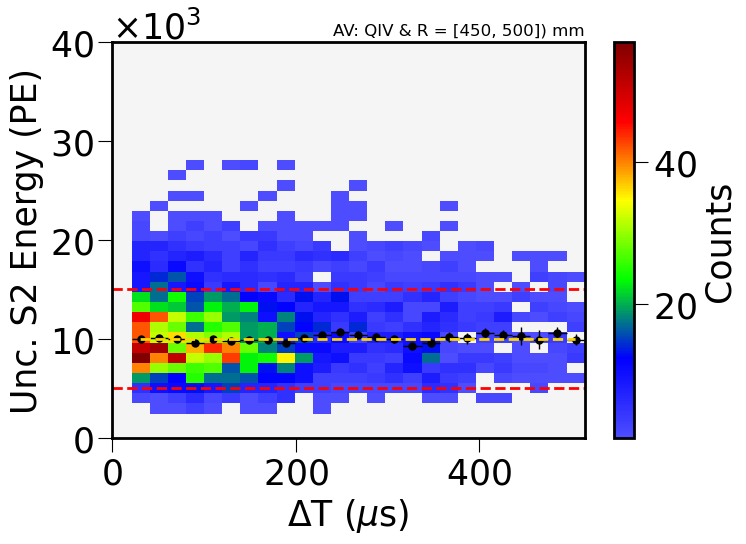

In [158]:
# Global
rad_lim = [150, 300, 450, 500]
DORO_DF['lifetime'] = np.zeros_like(DORO_DF['S2e'])

# Use exponential decay function with b = 0
def exp_bfixed(x, N0, tau):
    return crudo.ff.exponential_decay(x, N0, tau, 0)

# Variables
E2 = DORO_DF['S2e']
DT = DORO_DF['DT']
X = DORO_DF['X']
Y = DORO_DF['Y']
R = np.sqrt(X**2 + Y**2)


quadrants = [
                {"name": "QI"  , "mask": (X >= 0) & (Y >= 0)},
                {"name": "QII" , "mask": (X < 0)  & (Y >= 0)},
                {"name": "QIII", "mask": (X < 0)  & (Y < 0)},
                {"name": "QIV" , "mask": (X >= 0) & (Y < 0)},
            ]

for quadrant in quadrants:
    for i, r_lim in enumerate(rad_lim):

        if i == 0: r_min = 0
        else:      r_min = rad_lim[i-1]
        print(f"Processing: {quadrant['name']} & R = [{r_min}, {r_lim}) mm")

        # Masking
        mask = EXTRA_INFO['AV_Z_mask'] & quadrant["mask"] & (R >= r_min) & (R < r_lim)
        E2_mask = E2[mask]
        DT_mask = DT[mask]

        # Preliminary
        DT_down = DT_mask.min();    DT_up = DT_mask.max()
        E2_down = 15e3;  E2_up = 30e3
        if   i == 2:  E2_down = 5e3; E2_up = 25e3
        elif i == 3:  E2_down = 5e3; E2_up = 15e3

        # 2D histogram: normalized by corrected DAQ data taking time
        S2e_DT_map, ex, ey = np.histogram2d(DT_mask, E2_mask, bins=[25, 25])
        S2e_DT_map = np.ma.masked_where(S2e_DT_map == 0, S2e_DT_map)

        # ---- Exponential Fit ----- #
        # Filter the data for the fit
        fit_region_mask = (DT_mask >= DT_down) & (DT_mask <= DT_up) & \
                          (E2_mask >= E2_down) & (E2_mask <= E2_up)
        DT_fit = DT_mask[fit_region_mask]
        E2_fit = E2_mask[fit_region_mask]

        # Compute representative values for the fit
        DT_centers, DT_errors, S2e_means, S2e_errors = crudo.ff.prefit_2D(DT_fit, E2_fit, bins=ex)
        # Filter out points with zero error (bins with 1 event)
        valid_points = S2e_errors > 0
        DT_centers = DT_centers[valid_points]
        DT_errors = DT_errors[valid_points]
        S2e_means = S2e_means[valid_points]
        S2e_errors = S2e_errors[valid_points]

        # # Check if filtered data is not empty
        # if len(DT_centers) == 0 or len(S2e_means) == 0 or len(S2e_errors) == 0:
        #     print(f"Skipping fit for {quadrant['name']} with R in [{r_min}, {r_lim}] due to insufficient data.")
        #     continue

        # Define the cost function + initial guess
        least_squares = LeastSquares(DT_centers, S2e_means, S2e_errors, exp_bfixed)
        init_guess = [S2e_means.max(), (DT_centers.max() - DT_centers.min()) / 2]

        # Define the Minuit object
        m = Minuit(least_squares, *init_guess)

        # Minimization process of the cost function and error estimation
        m.migrad()
        m.hesse()

        # Results
        popt = m.values
        perr = m.errors
        print(f'Fit: N0 = ({popt[0]:.2f} ± {perr[0]:.2f}) PE, τ = ({popt[1] / 1e3:.2f} ± {perr[1] / 1e3:.2f}) ms')

        # Reduced chi-square
        chi2 = m.fval
        ndof = len(DT_centers) - m.nfit
        print(f"     χ² / ndof = {chi2 / ndof:.4f}")

        # ----- Plotting ----- #
        plt.figure(figsize=(8, 6))
        # Data
        plt.pcolormesh(ex, ey, S2e_DT_map.T, cmap=crudo.pt.custom_hsv, shading='auto')
        cbar = plt.colorbar(label='Counts', shrink=1.0)

        # Fit
        fit_y = exp_bfixed(DT_centers, *popt)
        plt.errorbar(DT_centers, S2e_means, xerr=DT_errors, yerr=S2e_errors, fmt='o', c='black', ecolor='black', lw=1.0, markersize=5)
        plt.plot(DT_centers, fit_y, c='gold', ls='--', zorder=3)
        plt.axhline(y=E2_down, c='red', ls='--')
        plt.axhline(y=E2_up, c='red', ls='--')

        # ----- Styling ----- #
        plt.xlabel('$\Delta$T ($\mu$s)')
        plt.xlim(0, DT_mask.max())
        plt.ylabel('Unc. S2 Energy (PE)')
        plt.ylim(0, 40e3)
        plt.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
        plt.title(f'AV: {quadrant["name"]} & R = [{r_min}, {r_lim}]) mm', fontsize=12, loc='right')

        plt.gca().set_facecolor("whitesmoke")
        plt.tight_layout()
        plt.show()

In [10]:
FIT_PARAMETERS

{'16047_v0727': {'S1e': {'m_CV': 0.15192661091192416,
   'm_err': 0.0009626007993891276,
   'b_CV': 54.392914846240046,
   'b_err': 0.23211921336360103},
  'S2e': {'N0_CV': 22481.52432174707,
   'N0_err': 38.63992174453487,
   'tau_CV': 41033.266788394896,
   'tau_err': 9449.750290470514}},
 '16057_v0727': {'S1e': {'m_CV': 0.15564513183711348,
   'm_err': 0.001202056533041221,
   'b_CV': 52.723243607879,
   'b_err': 0.2762790059621478},
  'S2e': {'N0_CV': 22474.163836831467,
   'N0_err': 46.62189209030172,
   'tau_CV': 36079.71306835622,
   'tau_err': 8826.115078728644}}}